In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.tsa.filters.hp_filter import hpfilter

os.chdir(r"C:\Users\Alejandro\Documents\Msc Analisis Economico Cuantitativo UAM\Courses\Quantitative Methods for Macroeconomics\France Business Cycle\data")

colnames = ['GDP (martket price)',
 'Final Consumption Expenditure of General Government',
 'Household and NPISH final consumption expenditure',
 'Gross capital formation',
 'Export of Goods',
 'Export of Services',
 'Import of Goods',
 'Import of Services',
 "Consumption of durable goods",
 "Consumption of semi-durable goods",
 "Consumption of non-durable goods",
 "Consumption of services",
 "Gross construction capital",
 "Gross machinery and weapon system capital",
 "Gross biological resources capital",
 "Gross intellectual property products capital"
]

plot_size = (15,8)
plt.style.use('dark_background')

**Unidades**: Indices de volumn encadenado 2015 = 100
<br>
**Frecuencia**: Q

# Data Preparation

In [2]:
# Getting the data ready

df = pd.read_excel(r"GDP_and_components.xlsx", sheet_name="France",skiprows=1)

# Change to long format
df = df.T
df = df.iloc[1:,]
df.columns  = colnames

# Set index to datetime
df.index = pd.PeriodIndex(df.index, freq='Q')

# Remove missing values
df.dropna(inplace=True)

# Create net exports
df["Net Exports of Goods"] = df["Export of Goods"] - df["Import of Goods"]
df["Net Exports of Services"] = df["Export of Services"] - df["Import of Services"]
df["Net Exports"] = df["Net Exports of Goods"] + df["Net Exports of Services"]

# Compute the cycle and trend for all columns in df
cycle = df.apply(lambda col: hpfilter(col, lamb=1600)[0])
trend = df.apply(lambda col: hpfilter(col, lamb=1600)[1])


# Import data (shares are already calculated in excel)
shares = pd.read_excel("GDP_shares.xlsx", sheet_name="France_data_mp",skiprows=1,parse_dates=["Date"])
shares.drop(columns=["Unnamed: 0"], inplace=True)
shares.set_index(pd.PeriodIndex(shares["Date"].dt.to_period("Q")), inplace=True)

# Separate volumes from share
volume = shares[['GDP at market prices', 'Final consumption', 'GCF', 'Net Exports']].__deepcopy__()
shares.drop(columns=["Date",'GDP at market prices', 'Final consumption', 'GCF', 'Net Exports'], inplace=True)

# Compute the average contribution to GDP
for col in shares.columns:
    shares[f"{col} average"] = shares[col].mean()

# Store the recession periods

peak_quarters = ["1980Q1", "1992Q1", "2008Q1", "2019Q4"]
trough_quarters = ["1980Q4", "1993Q1", "2009Q2", "2020Q2"]

peaks = pd.PeriodIndex(peak_quarters, freq="Q")
troughs = pd.PeriodIndex(trough_quarters, freq="Q")

# Store main gpd components
gdp_components = [
       'Final Consumption Expenditure of General Government',
       'Household and NPISH final consumption expenditure',
       'Gross capital formation', 'Net Exports of Goods',
       'Net Exports of Services']

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_12380\1693341907.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shares = pd.read_excel("GDP_shares.xlsx", sheet_name="France_data_mp",skiprows=1,parse_dates=["Date"])


# Data Ploting

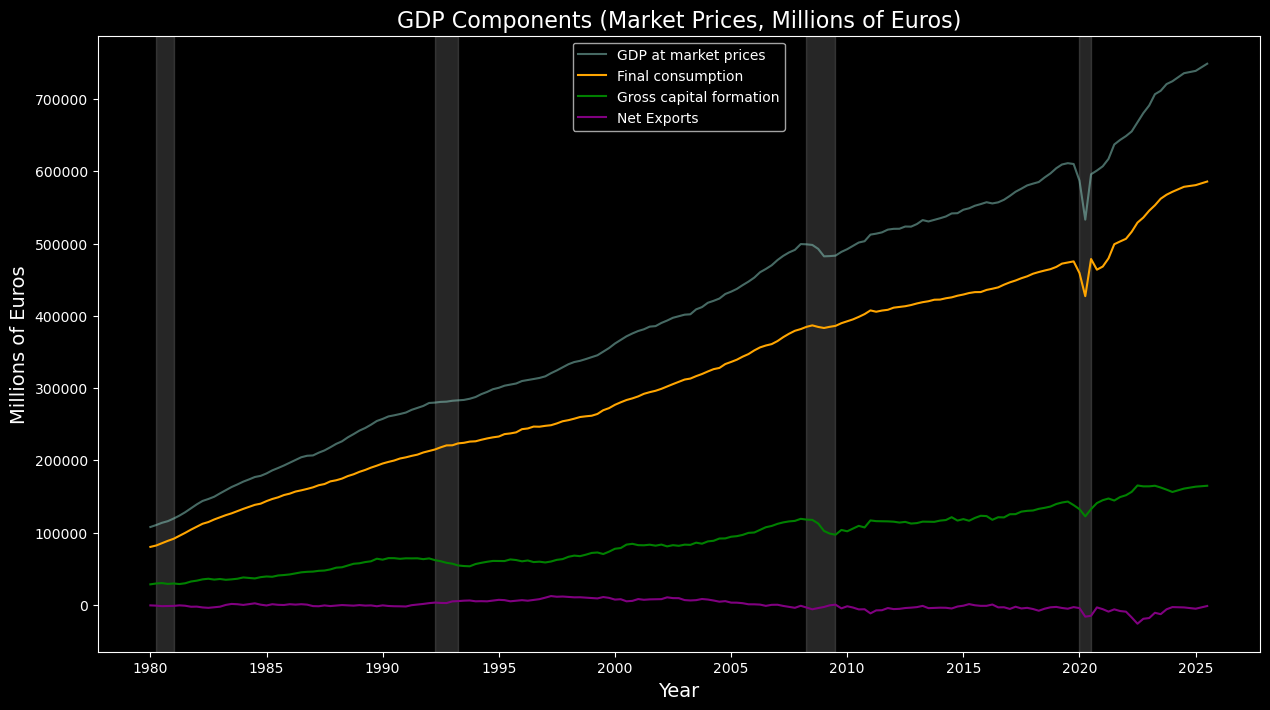

In [3]:
plt.figure(figsize=plot_size)

plt.plot(volume.index.to_timestamp(), volume['GDP at market prices'], label='GDP at market prices', alpha=0.5)
plt.plot(volume.index.to_timestamp(), volume['Final consumption'], label='Final consumption', color='orange')
plt.plot(volume.index.to_timestamp(), volume['GCF'], label='Gross capital formation', color='green')
plt.plot(volume.index.to_timestamp(), volume['Net Exports'], label='Net Exports', color='purple')

for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

plt.title('GDP Components (Market Prices, Millions of Euros)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Millions of Euros', fontsize=14)
plt.legend()
plt.show()

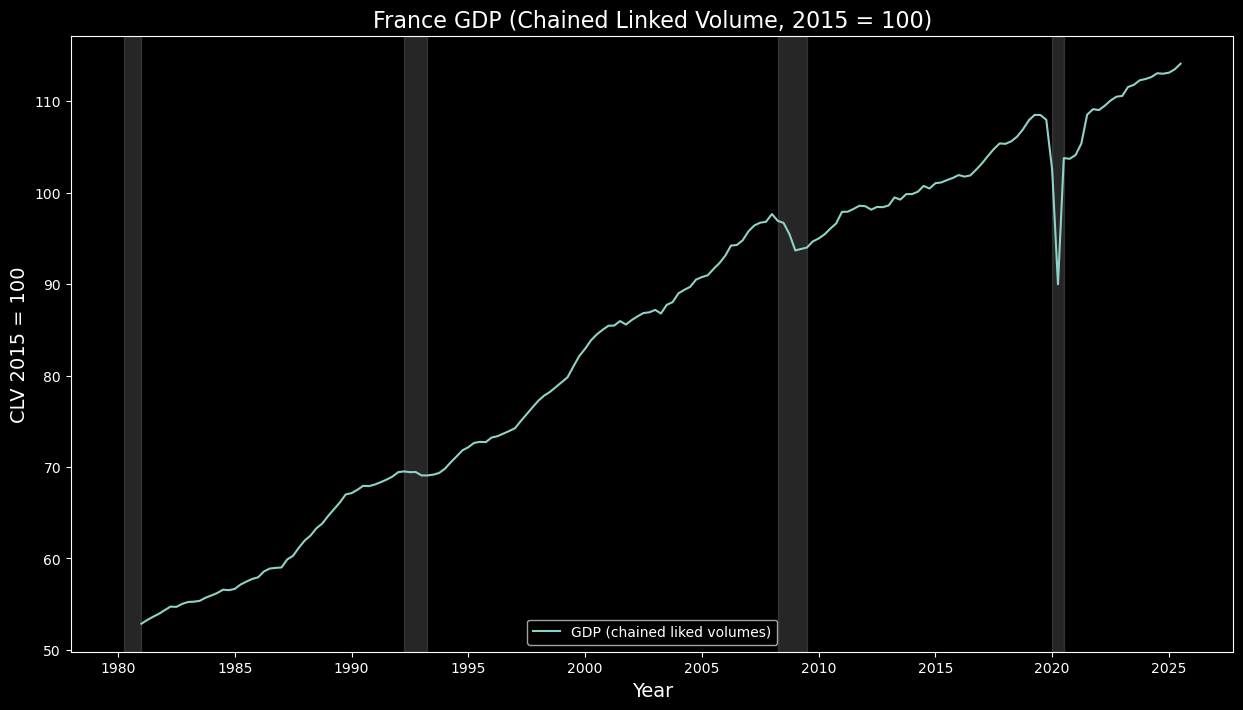

In [4]:
# GDP Plot
plt.figure(figsize=plot_size)
# Time series plot
plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label='GDP (chained liked volumes)')
# Shade recession intervals
for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

plt.title('France GDP (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()
plt.show()

### Consumption series

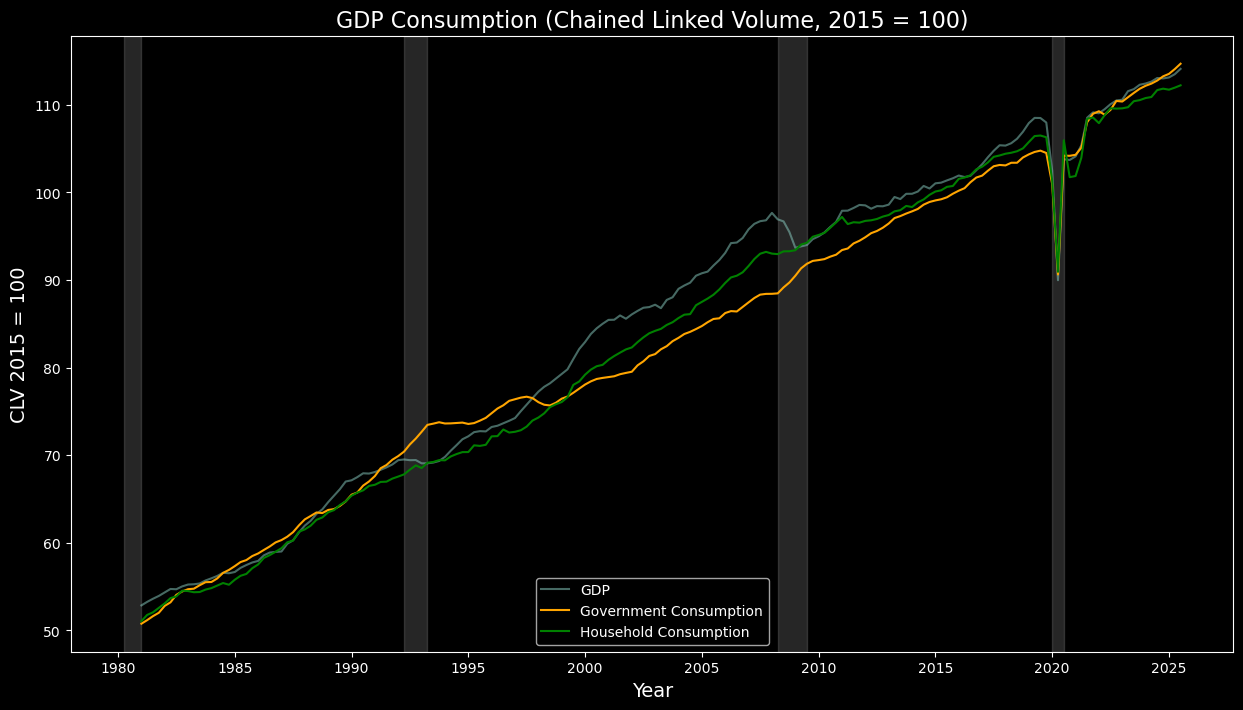

In [5]:
# GDP compoenents plot
plt.figure(figsize=plot_size)

plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label='GDP', alpha=0.5)
plt.plot(df.index.to_timestamp(), df['Final Consumption Expenditure of General Government'], label='Government Consumption', color='orange')
plt.plot(df.index.to_timestamp(), df['Household and NPISH final consumption expenditure'], label='Household Consumption', color='green')

for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

plt.title('GDP Consumption (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()
plt.show()


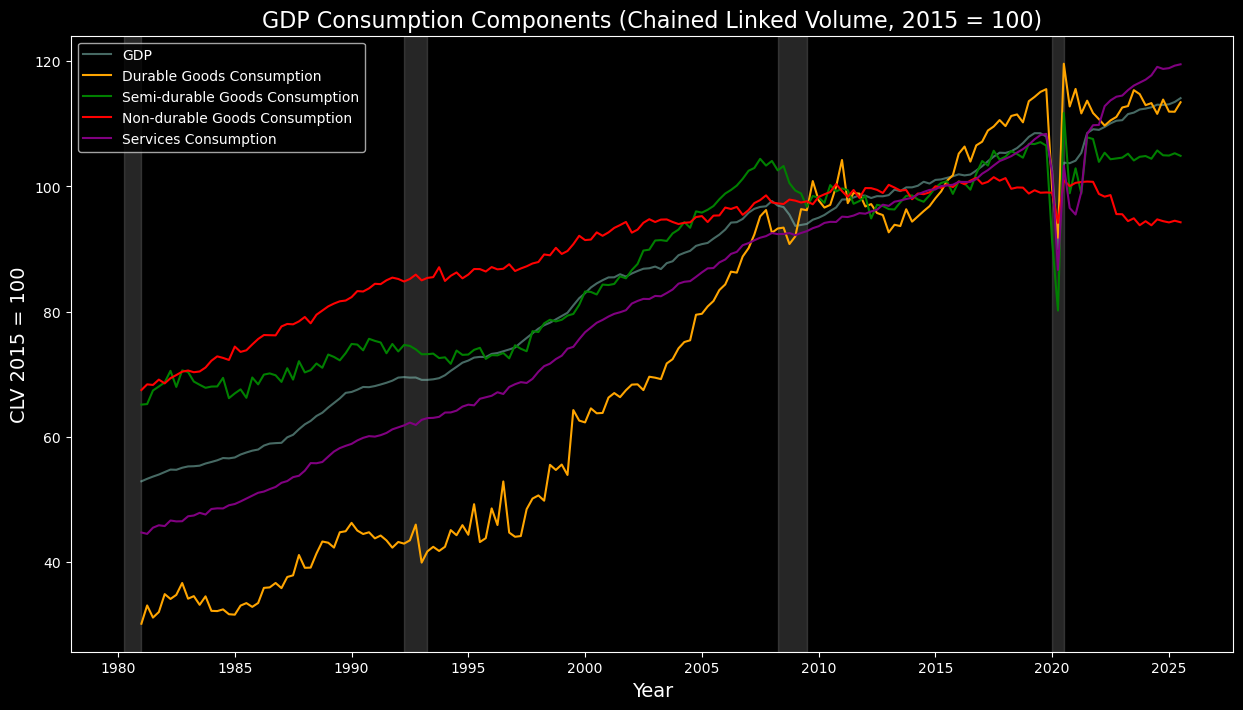

In [6]:
# Consumtion components plot
plt.figure(figsize=plot_size)

plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label='GDP', alpha=0.5)
plt.plot(df.index.to_timestamp(), df["Consumption of durable goods"], label='Durable Goods Consumption', color='orange')
plt.plot(df.index.to_timestamp(), df["Consumption of semi-durable goods"], label='Semi-durable Goods Consumption', color='green')
plt.plot(df.index.to_timestamp(), df["Consumption of non-durable goods"], label='Non-durable Goods Consumption', color='red')
plt.plot(df.index.to_timestamp(), df["Consumption of services"], label='Services Consumption', color='purple')
for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

plt.title('GDP Consumption Components (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()
plt.show()

### Investment Series

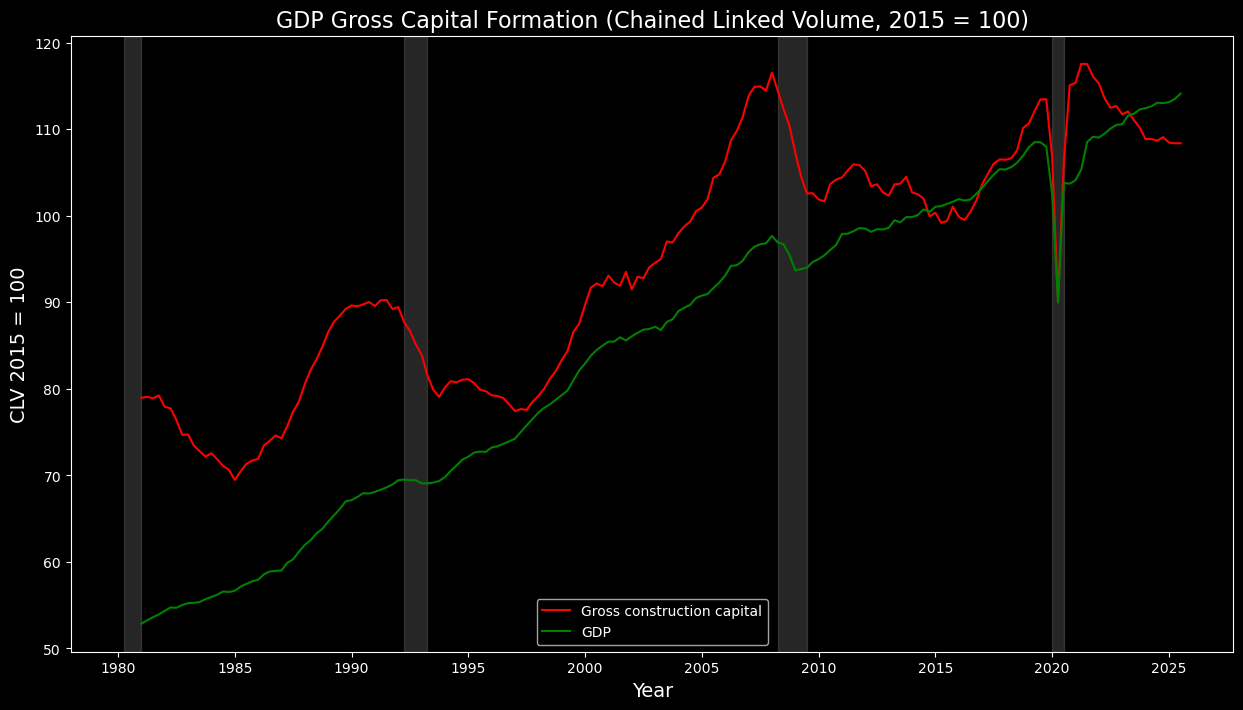

In [7]:
plt.figure(figsize=plot_size)
plt.plot(df.index.to_timestamp(), df['Gross construction capital'], label="Gross construction capital", color='red')
plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label="GDP", color='green')
for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)
plt.title('GDP Gross Capital Formation (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()
plt.show()


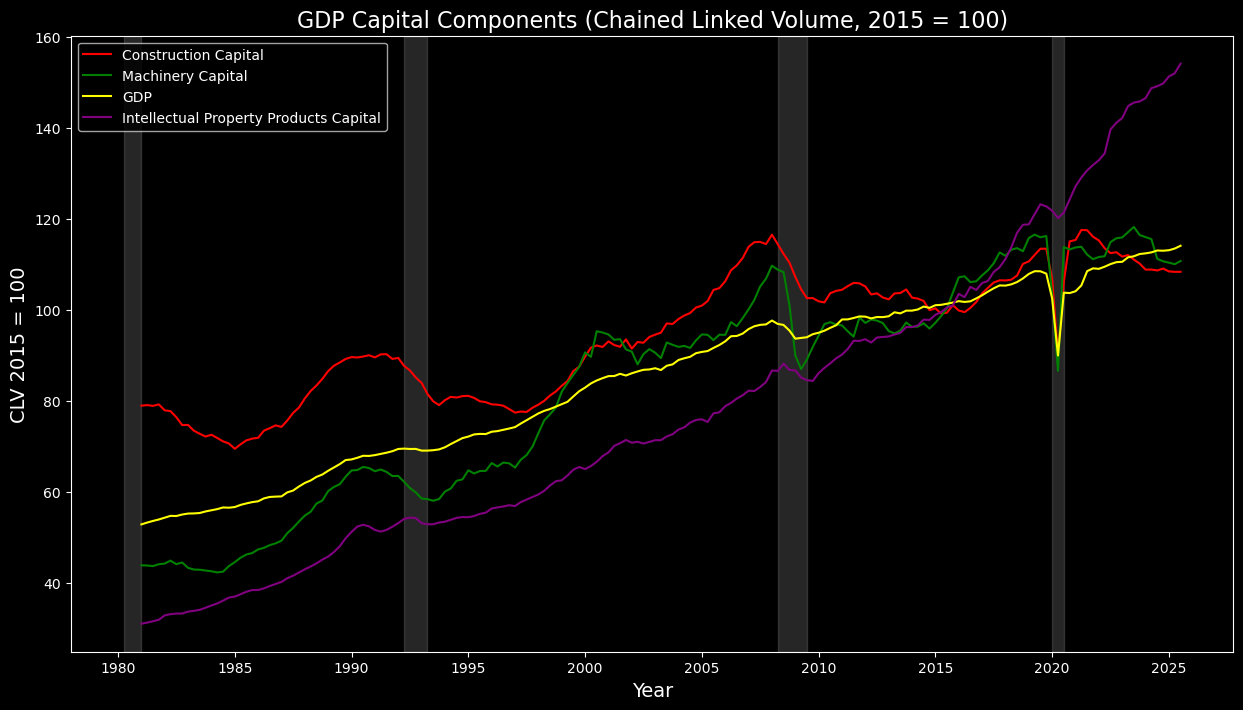

In [8]:
plt.figure(figsize=plot_size)
plt.plot(df.index.to_timestamp(), df['Gross construction capital'], label='Construction Capital', color='red')
plt.plot(df.index.to_timestamp(), df['Gross machinery and weapon system capital'], label='Machinery Capital', color='green')
plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label="GDP", color='yellow')
# plt.plot(df.index.to_timestamp(), df['Gross biological resources capital'], label='Biological Resources Capital', color='orange')
plt.plot(df.index.to_timestamp(), df['Gross intellectual property products capital'], label='Intellectual Property Products Capital', color='purple')
for start, end in zip(peaks, troughs):
    plt.axvspan(start, end, color="gray", alpha=0.3)
plt.title('GDP Capital Components (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()

### Exports and imports

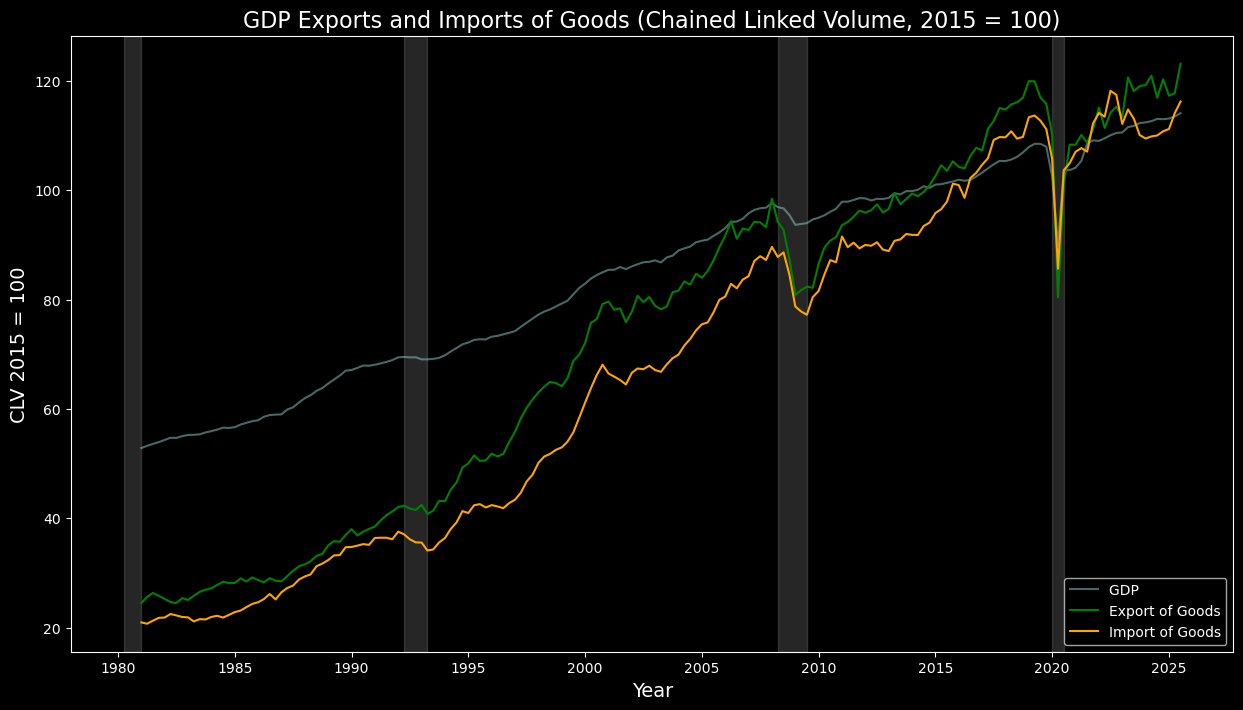

In [9]:
plt.figure(figsize=plot_size)
plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label='GDP ', alpha=0.5)
plt.plot(df.index.to_timestamp(), df['Export of Goods'], label='Export of Goods', color='green')
plt.plot(df.index.to_timestamp(), df['Import of Goods'], label='Import of Goods', color='orange')
plt.title('GDP Exports and Imports of Goods (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()
for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

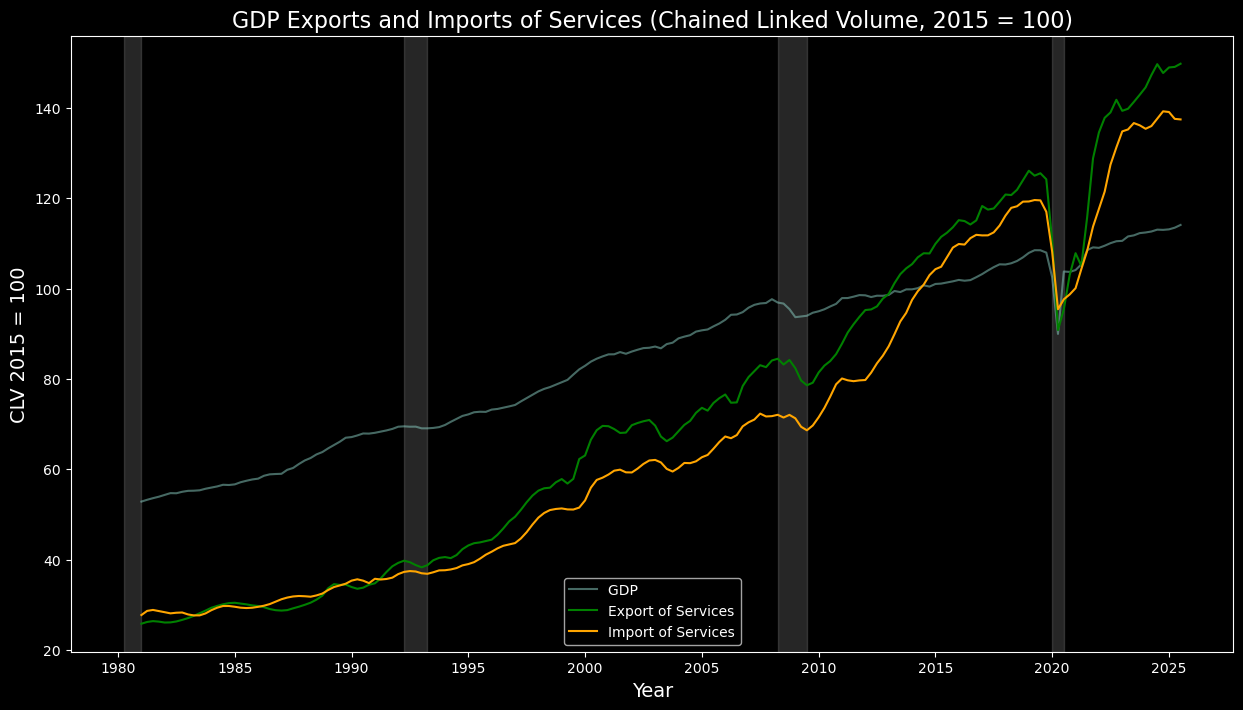

In [10]:
plt.figure(figsize=plot_size)
plt.plot(df.index.to_timestamp(), df['GDP (martket price)'], label='GDP ', alpha=0.5)
plt.plot(df.index.to_timestamp(), df['Export of Services'], label='Export of Services', color='green')
plt.plot(df.index.to_timestamp(), df['Import of Services'], label='Import of Services', color='orange')
plt.title('GDP Exports and Imports of Services (Chained Linked Volume, 2015 = 100)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CLV 2015 = 100', fontsize=14)
plt.legend()
for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

# Shares and growth rates of the main components

Units: market price, millions of Euros

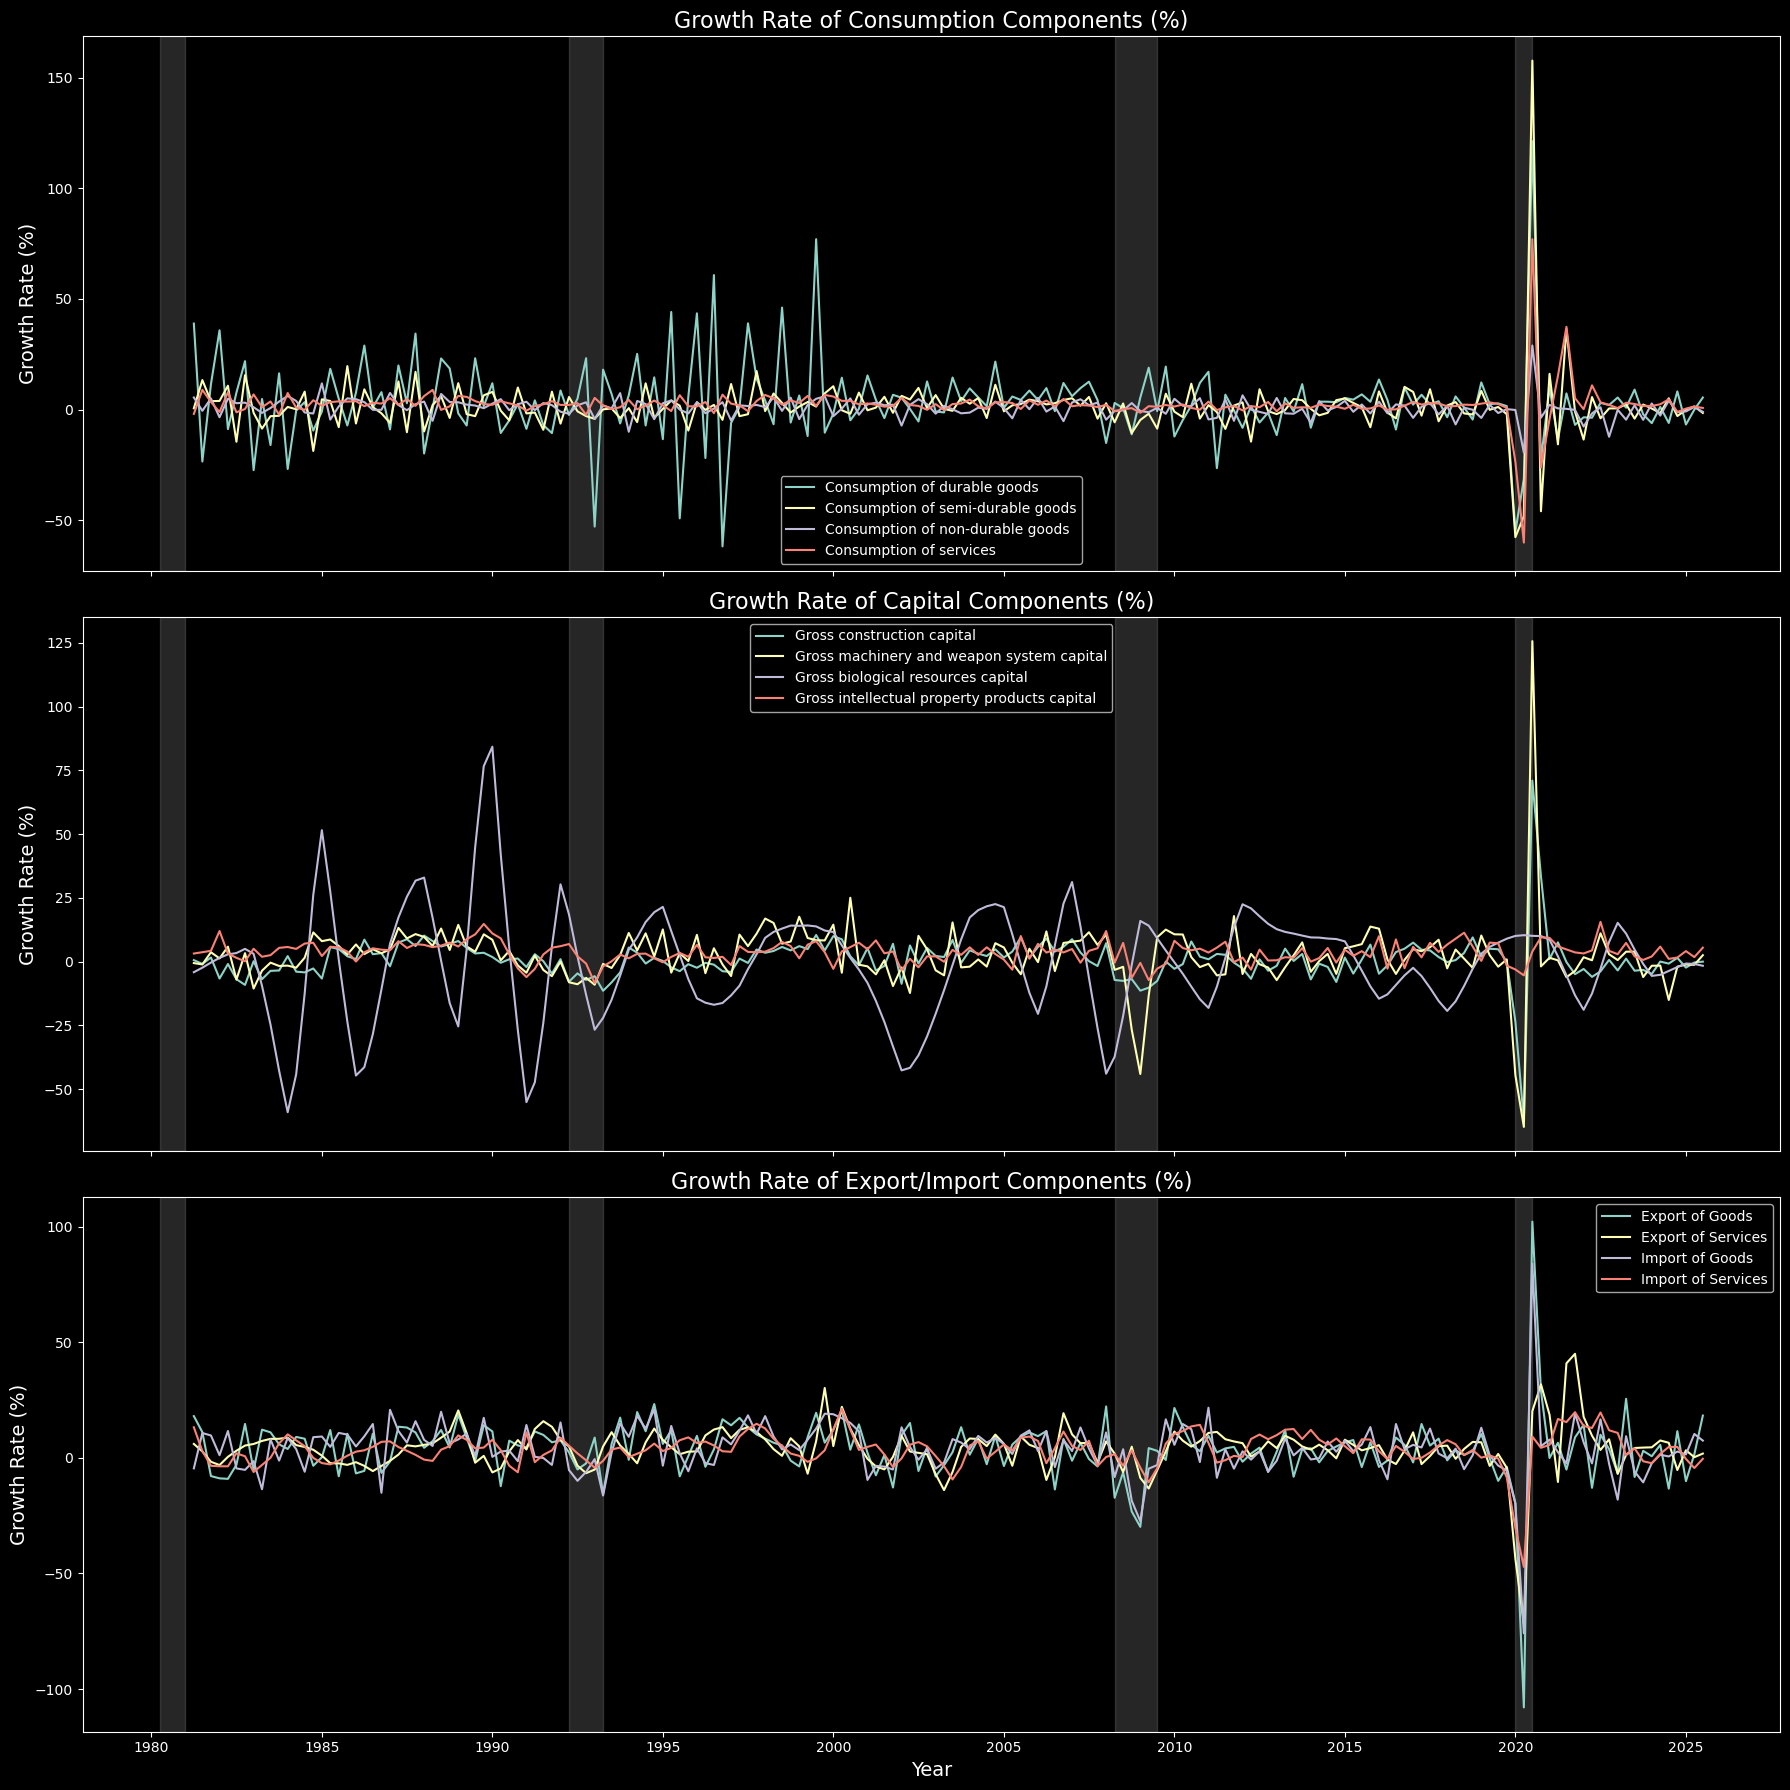

In [11]:
# Compute percentage change for all columns in df (convert to float first)
df_pct = df.astype(float).pct_change() * 400

fig, axs = plt.subplots(3, 1, figsize=(18, 18), sharex=True)

# 1. Consumption components
cons_cols = [
    "Consumption of durable goods",
    "Consumption of semi-durable goods",
    "Consumption of non-durable goods",
    "Consumption of services"
]
for col in cons_cols:
    axs[0].plot(df_pct.index.to_timestamp(), df_pct[col], label=col)
axs[0].set_title("Growth Rate of Consumption Components (%)", fontsize=16)
axs[0].set_ylabel("Growth Rate (%)", fontsize=14)
axs[0].legend()
for start, end in zip(peaks, troughs):
    axs[0].axvspan(start, end, color="gray", alpha=0.3)

# 2. Capital components
cap_cols = [
    "Gross construction capital",
    "Gross machinery and weapon system capital",
    "Gross biological resources capital",
    "Gross intellectual property products capital"
]
for col in cap_cols:
    axs[1].plot(df_pct.index.to_timestamp(), df_pct[col], label=col)
axs[1].set_title("Growth Rate of Capital Components (%)", fontsize=16)
axs[1].set_ylabel("Growth Rate (%)", fontsize=14)
axs[1].legend()
for start, end in zip(peaks, troughs):
    axs[1].axvspan(start, end, color="gray", alpha=0.3)

# 3. Export components
exp_cols = [
    "Export of Goods",
    "Export of Services",
    "Import of Goods",
    "Import of Services",
    #"Net Exports"
]
for col in exp_cols:
    axs[2].plot(df_pct.index.to_timestamp(), df_pct[col], label=col)
axs[2].set_title("Growth Rate of Export/Import Components (%)", fontsize=16)
axs[2].set_xlabel("Year", fontsize=14)
axs[2].set_ylabel("Growth Rate (%)", fontsize=14)
axs[2].legend()
for start, end in zip(peaks, troughs):
    axs[2].axvspan(start, end, color="gray", alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_17696\3454873444.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_fc = shares['Share of Final consumption average'][0]
C:\Users\Alejandro\AppData\Local\Temp\ipykernel_17696\3454873444.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_gcf = shares['Share of GCF average'][0]
C:\Users\Alejandro\AppData\Local\Temp\ipykernel_17696\3454873444.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use 

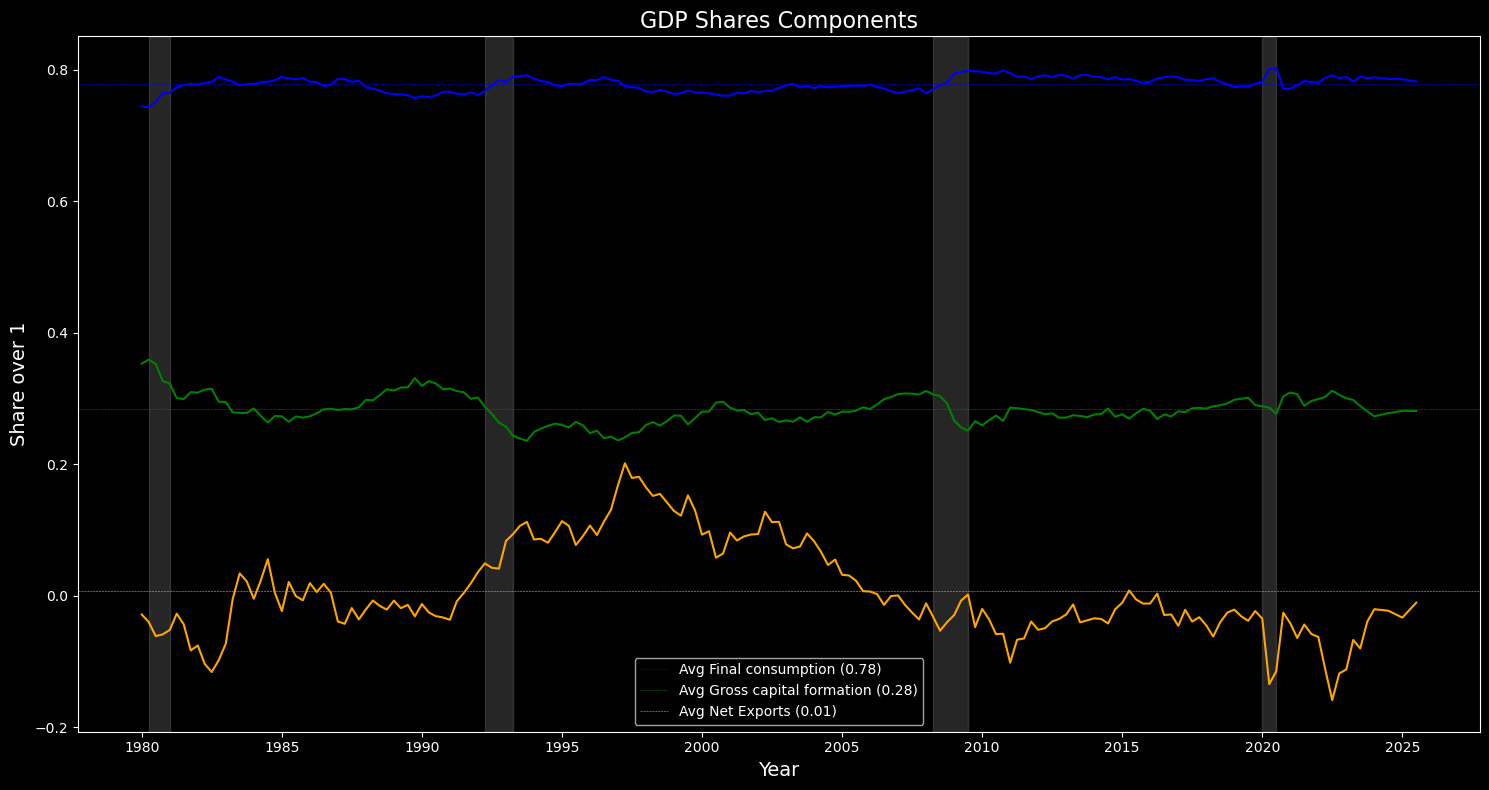

In [12]:
plt.figure(figsize=plot_size)

# Plot the shares WITHOUT labels (so they don't appear in the legend)
plt.plot(shares.index.to_timestamp(), shares['Share of Final consumption'], color='blue')
plt.plot(shares.index.to_timestamp(), shares['Share of Net Exports'], color='orange')
plt.plot(shares.index.to_timestamp(), shares['Share of GCF'], color='green')

# Extract averages
avg_fc = shares['Share of Final consumption average'][0]
avg_gcf = shares['Share of GCF average'][0]
avg_ne = shares['Share of Net Exports average'][0]

# Plot averages WITH f-string labels
plt.axhline(y=avg_fc, color='blue', linestyle='--', linewidth=0.4,
            label=f'Avg Final consumption ({avg_fc:.2f})')

plt.axhline(y=avg_gcf, color='green', linestyle='--', linewidth=0.4,
            label=f'Avg Gross capital formation ({avg_gcf:.2f})')

plt.axhline(y=avg_ne, color='orange', linestyle='--', linewidth=0.4,
            label=f'Avg Net Exports ({avg_ne:.2f})')

plt.title('GDP Shares Components', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Share over 1', fontsize=14)

plt.legend()

# Shaded recession periods
for start, end in zip(peaks, troughs): 
    plt.axvspan(start, end, color="gray", alpha=0.3)

plt.tight_layout()


# Trend extraction 

We will extract the trend from the time series components and the GDP. We will use chained linked volumes time series, since they provide a inflation-free volumes and a common unit of measure for the time series. We won´t take logs of any series.

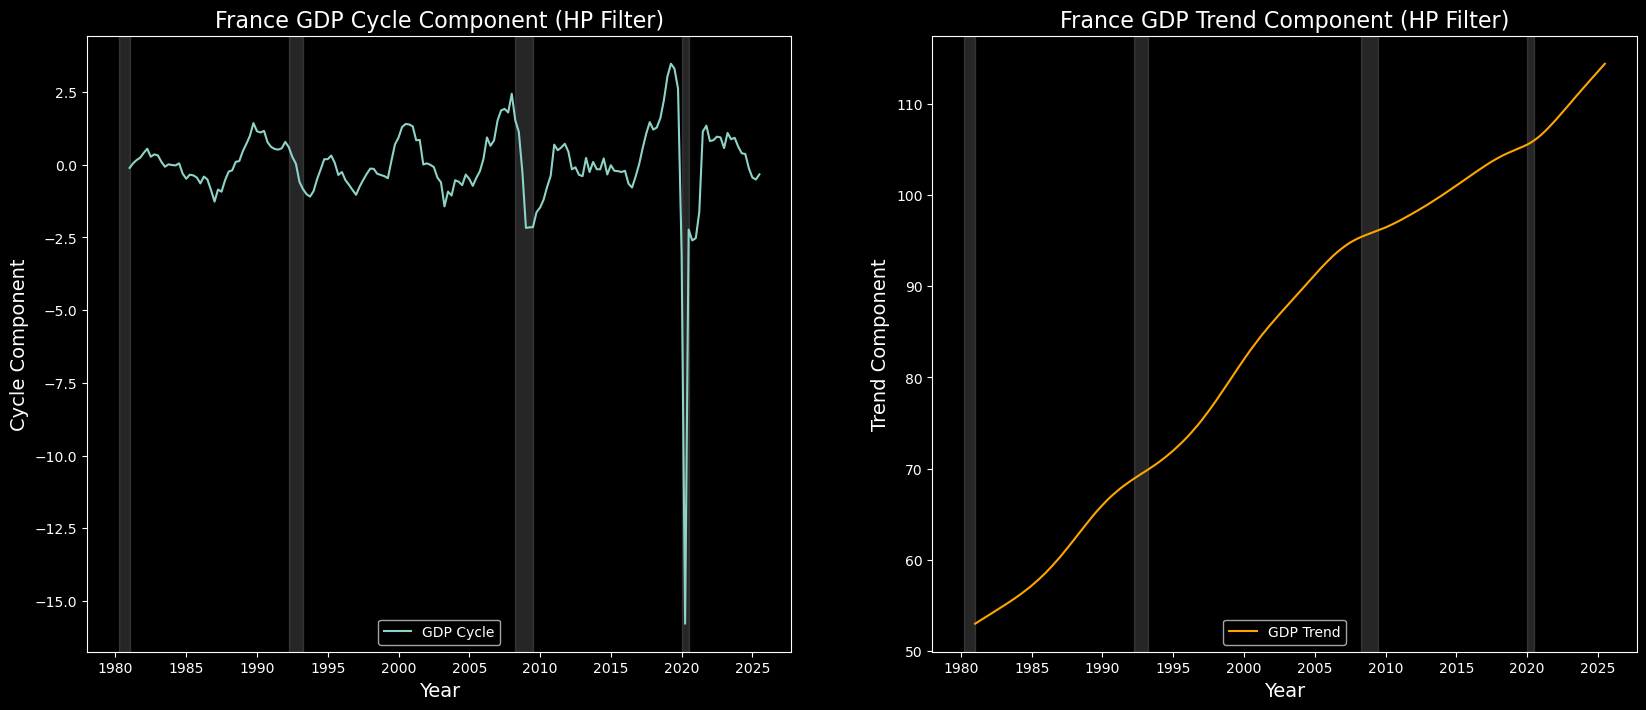

In [13]:

gdp_cycle, gdp_trend = hpfilter(df['GDP (martket price)'], lamb=1600)

fig, ax = plt.subplots(1, 2, figsize=(20,8))

ax[0].plot(df.index.to_timestamp(), gdp_cycle, label='GDP Cycle')
ax[1].plot(df.index.to_timestamp(), gdp_trend, label='GDP Trend', color='orange')

# Shade recession periods
for start, end in zip(peaks, troughs):
    ax[0].axvspan(start, end, color="gray", alpha=0.3)
    ax[1].axvspan(start, end, color="gray", alpha=0.3)

# Titles and labels
ax[0].set_title('France GDP Cycle Component (HP Filter)', fontsize=16)
ax[1].set_title('France GDP Trend Component (HP Filter)', fontsize=16)

ax[0].set_xlabel('Year', fontsize=14)
ax[0].set_ylabel('Cycle Component', fontsize=14)

ax[1].set_xlabel('Year', fontsize=14)
ax[1].set_ylabel('Trend Component', fontsize=14)

ax[0].legend()
ax[1].legend()

plt.show()




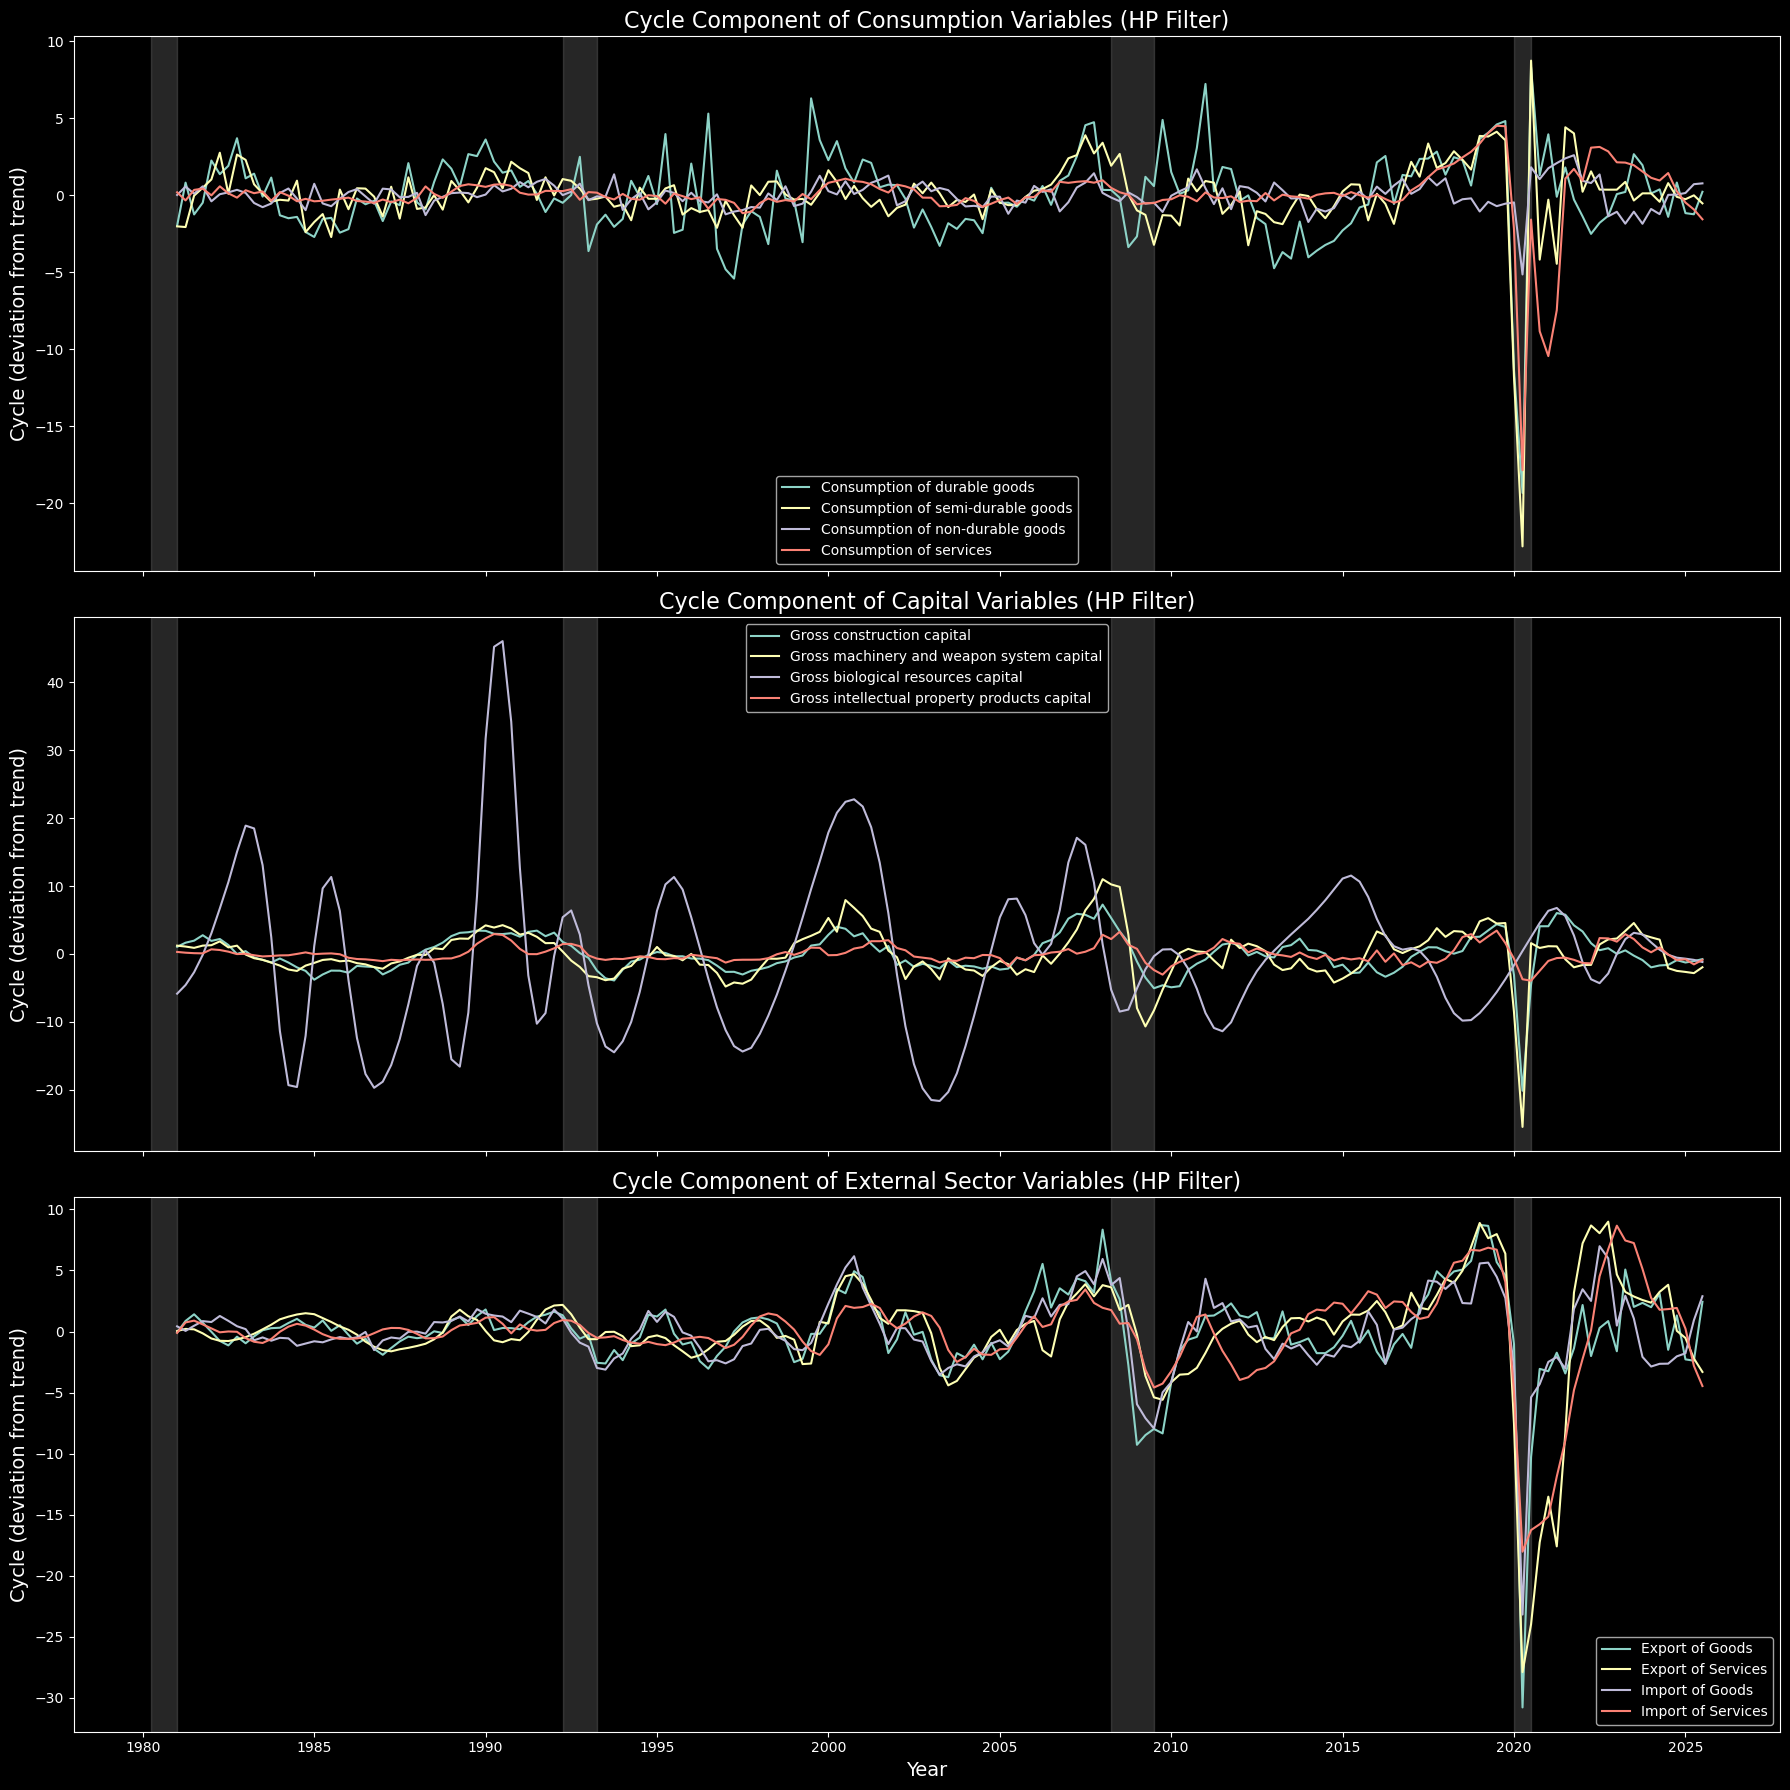

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(18, 18), sharex=True)

# 1. Consumption components (cycle)
cons_cols = [
    "Consumption of durable goods",
    "Consumption of semi-durable goods",
    "Consumption of non-durable goods",
    "Consumption of services"
]
for col in cons_cols:
    axs[0].plot(cycle.index.to_timestamp(), cycle[col], label=col)

axs[0].set_title("Cycle Component of Consumption Variables (HP Filter)", fontsize=16)
axs[0].set_ylabel("Cycle (deviation from trend)", fontsize=14)
axs[0].legend()

for start, end in zip(peaks, troughs):
    axs[0].axvspan(start, end, color="gray", alpha=0.3)

# 2. Capital components (cycle)
cap_cols = [
    "Gross construction capital",
    "Gross machinery and weapon system capital",
    "Gross biological resources capital",
    "Gross intellectual property products capital"
]
for col in cap_cols:
    axs[1].plot(cycle.index.to_timestamp(), cycle[col], label=col)

axs[1].set_title("Cycle Component of Capital Variables (HP Filter)", fontsize=16)
axs[1].set_ylabel("Cycle (deviation from trend)", fontsize=14)
axs[1].legend()

for start, end in zip(peaks, troughs):
    axs[1].axvspan(start, end, color="gray", alpha=0.3)

# 3. External sector components (cycle)
exp_cols = [
    "Export of Goods",
    "Export of Services",
    "Import of Goods",
    "Import of Services"
]
for col in exp_cols:
    axs[2].plot(cycle.index.to_timestamp(), cycle[col], label=col)

axs[2].set_title("Cycle Component of External Sector Variables (HP Filter)", fontsize=16)
axs[2].set_xlabel("Year", fontsize=14)
axs[2].set_ylabel("Cycle (deviation from trend)", fontsize=14)
axs[2].legend()

for start, end in zip(peaks, troughs):
    axs[2].axvspan(start, end, color="gray", alpha=0.3)

plt.tight_layout()
plt.show()


# Correlation with the cycle

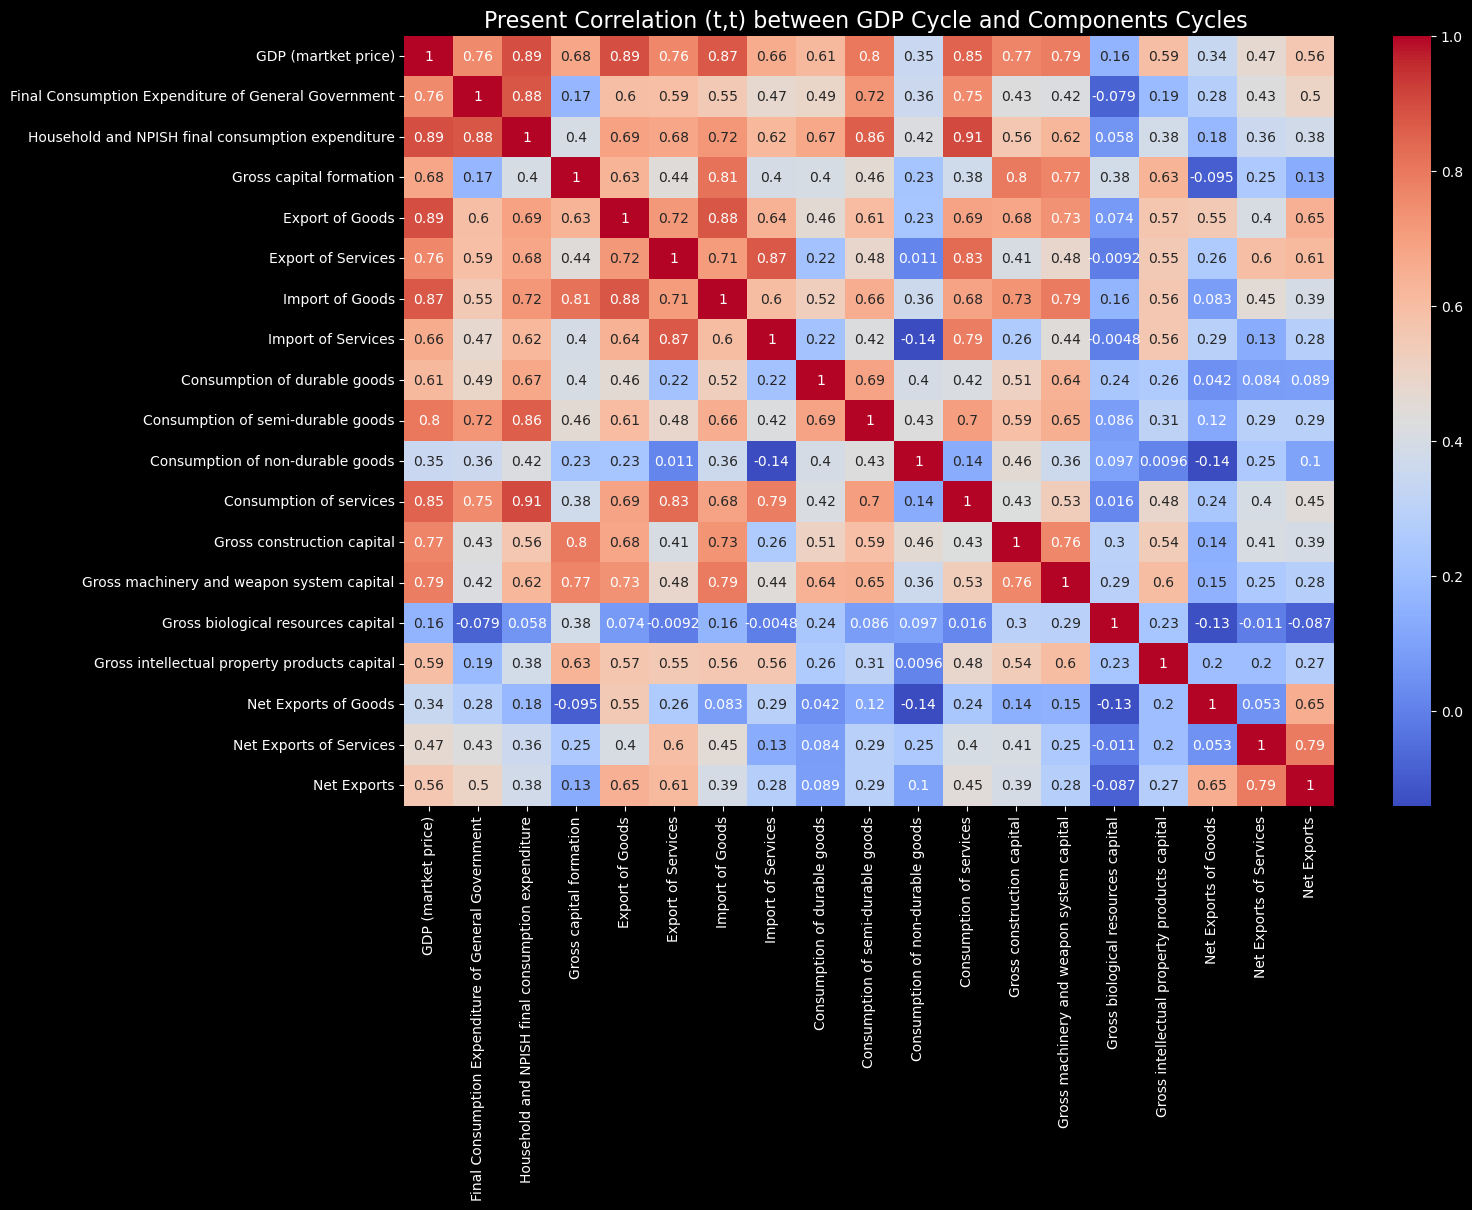

In [15]:
present_correlation = np.corrcoef(cycle, rowvar=False)

plt.figure(figsize=(15,10))
sns.heatmap(present_correlation, annot=True, xticklabels=cycle.columns, yticklabels=list(cycle.columns), cmap='coolwarm')
plt.title('Present Correlation (t,t) between GDP Cycle and Components Cycles ', fontsize=16)
plt.show()

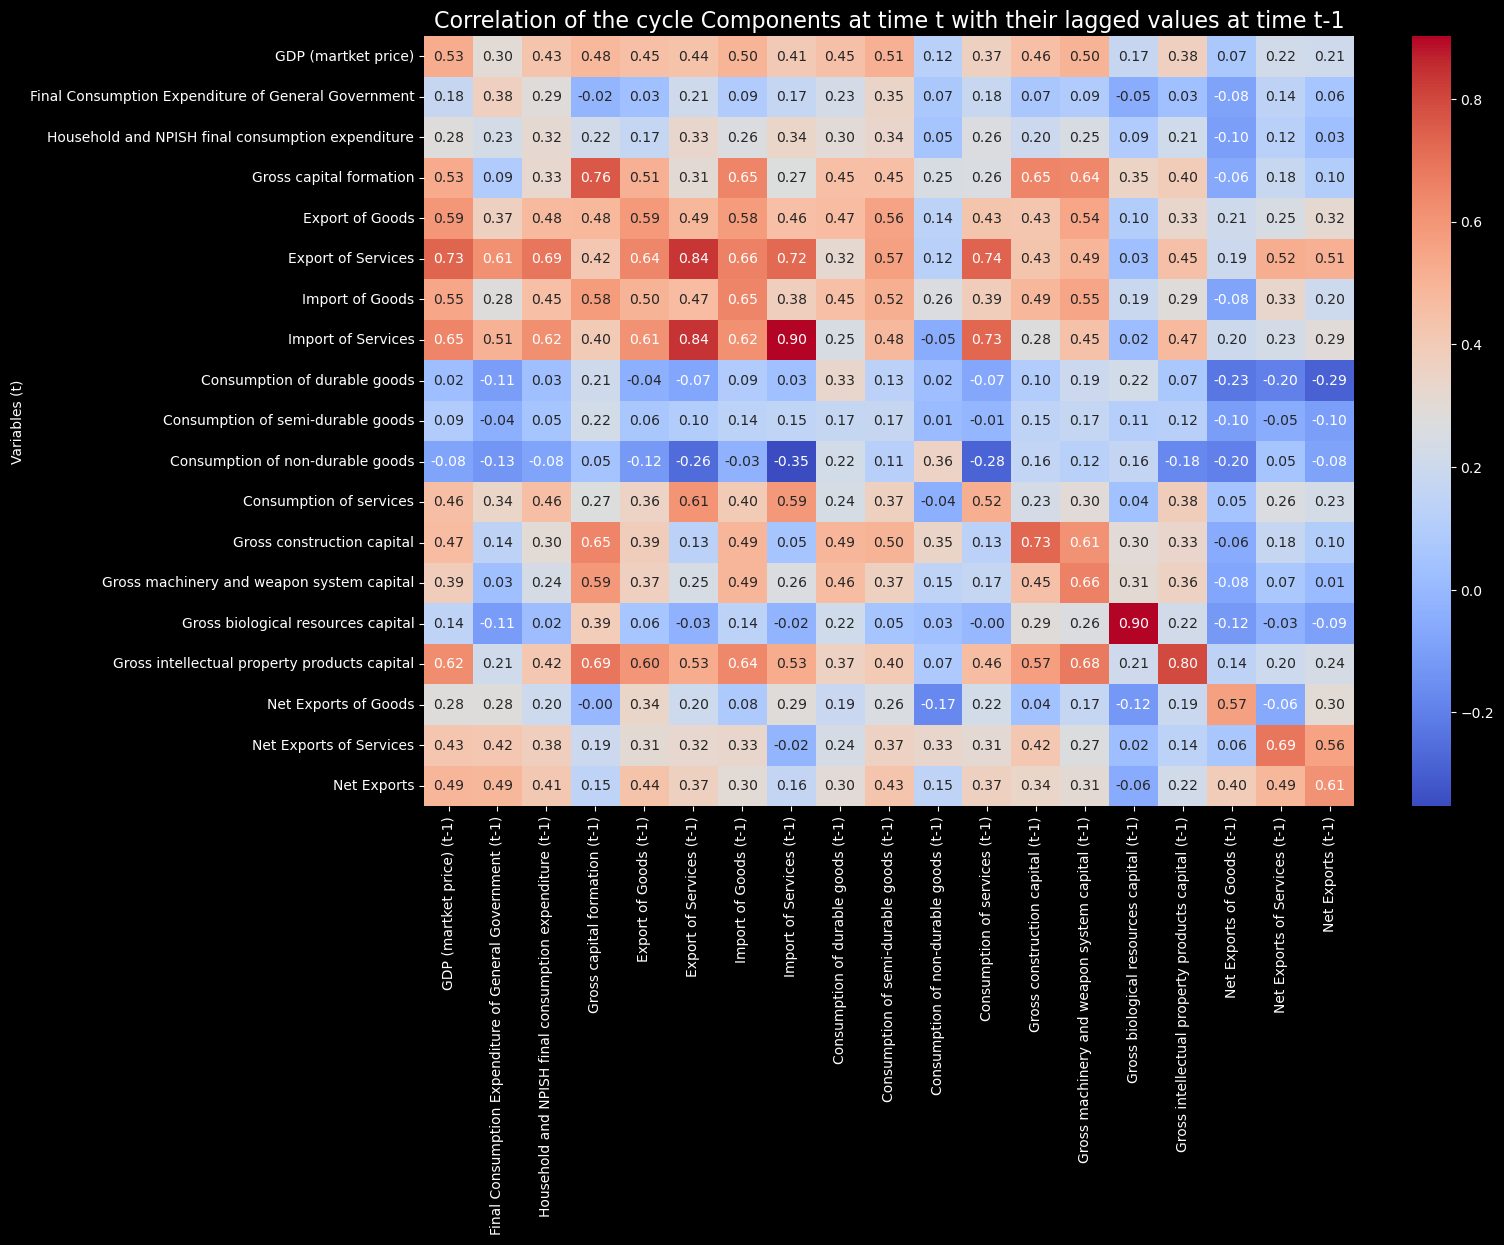

In [16]:
# 1. Concatenate 'cycle' (t) and 'cycle.shift(1)' (t-1)  (Pandas automatically handles the NaNs from the shift)
combined = pd.concat([cycle, cycle.shift(1)], axis=1)

# 2. Compute the full correlation matrix and slice the top-right quadrant immediately .iloc[:n, n:] takes the first n rows (t) and the last n columns (t-1)
n = cycle.shape[1]
lag_corr_matrix = combined.corr().iloc[:n, n:]

# 3. Clean up labels for clarity (Optional but recommended)
lag_corr_matrix.index.name = "Variables (t)"
lag_corr_matrix.columns = [f"{c} (t-1)" for c in cycle.columns]


# 4. Plot (Optional)
plt.figure(figsize=(15,10))
sns.heatmap(lag_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of the cycle Components at time t with their lagged values at time t-1", fontsize=16)
plt.show()



# Monthly indicators


In [14]:
# Getting the monthly data ready
m_d_colnames = [
    "Construction confidence indicator", "Economic sentiment indicator", 
    "Industrial confidence indicator", "Retail confidence indicator", 
    "Consumer confidence indicator", "Services confidence indicator", 
    "Expectation of the demand over the next 3 months", 
    "Expectation of the employment over the next 3 months", 
    "Services confidence indicator_alt", "Expectations of the prices over the next 3 months", 
    "Car registrations", "Consumers Financial situation over the last 12 months", 
    "Consumers Financial situation over the next 12 months", 
    "Consumers General economic situation over the last 12 months", 
    "Consumers General economic situation over the next 12 months", 
    "Consumers Price trends over the last 12 months", 
    "Consumers Price trends over the next 12 months", 
    "Consumers Unemployment expectations over the next 12 months", 
    "Consumers The current economic situation is adequate to make major purchases", 
    "Consumers Major purchases over the next 12 months", 
    "Consumers Savings over the next 12 months", 
    "Consumers Statement on financial situation of household", 
    "Consumers Consumer confidence indicator", 
    "Construction Evolution of the current overall order books", 
    "Construction Price expectations over the next 3 months", 
    "Construction confidence indicator_alt", 
    "Construction Factors limiting building activity - insufficient demand", 
    "Consumption of electricity - GWh", "Employment expectations over the next 3 months", 
    "Employment expectations over the next 3 months - industry", 
    "Assessment of order-book levels", "Assessment of export order-book levels", 
    "Assessment of the current level of stocks of finished products", 
    "Industrial confidence indicator_alt", "HICP - All items (Interanual Monthly Growth Rate)", 
    "Unemployment (over 25 - % of population in the labor force)",
    "Number of authorised dwellings",
    "Hotels Occupancy rate",
    "Air Passangers",
    "Number of started dwellings",
    "Business situation Retail trade",
    "Demand evolution Services",
    "Employment Construction",
    "Employment Manufacturing",
    "Employment Retail trade",
    "Employment Services",
    "Order intentions or demand Retail trade",
    "Production Manufacturing"
]


m_d_short = [ 
    "construction_conf", "economic_sentiment", "industrial_conf", "retail_conf", "consumer_conf", "services_conf", 
    "demand_exp_3m", "employment_exp_3m", "services_conf_alt", "price_exp_3m", "car_registrations", "fin_sit_last_12m", "fin_sit_next_12m", 
    "econ_sit_last_12m", "econ_sit_next_12m", "price_trend_last_12m", "price_trend_next_12m", "unemp_exp_12m", "major_purchases_now", 
    "major_purchases_12m", "savings_12m", "fin_sit_household", "consumer_conf_alt", "constr_order_books", "constr_price_exp_3m", 
    "construction_conf_alt", "constr_limit_demand", "electricity_gwh", "employment_exp", "employment_exp_industry", "order_book_level", 
    "export_order_book_level", "stocks_finished", "industrial_conf_alt", "hicp_yoy", "unemployment_over25", "authorised_dwellings" , "ocupancy_rate", "air_passangers", "started_dwellings",
    "business_sit_retail", "demand_evol_services", "employment_construction", "employment_manufacturing", "employment_retail", "employment_services", "order_intentions_retail", "production_manufacturing"
]

# 1. Sentiment & Confidence (The "Core 5" Sector Indicators + Export signal)
# Kept only the main headline indicators. "Industrial" is the best proxy for the GDP cycle.
# Added 'export_order_books' because distinct external shocks often drive the cycle.
sentiment_conf = [
    "industrial_conf", 
    "services_conf", 
    "consumer_conf", 
    "retail_conf", 
    "construction_conf"
]

# 2. Consumer-Specific (Forward-Looking Only)
# Removed backward-looking data (e.g., "last 12m") because past sentiment doesn't predict future growth.
# Kept 'major_purchases' (proxy for durable consumption) and 'unemployment_exp' (strong recession signal).
consumer_specific = [
    "unemp_exp_12m", 
    "econ_sit_next_12m",
    "savings_12m",
    "major_purchases_now"
]

# 3. Expectations & Assessments (Business Cycle Drivers)
# 'Demand' drives future output. 'Employment' drives future income. 
# Removed price expectations as they track inflation, not necessarily the growth cycle.
expectations_assessments = [
    "demand_exp_3m", 
    "employment_exp_3m", 
    "constr_order_books",
    "export_order_book_level",
    "business_sit_retail",
    "demand_evol_services",
    "order_intentions_retail"
]

# 4. Microeconomic Consumption (High-Frequency Hard Data)
# These are excellent real-activity proxies that often lead official GDP data.
micro_cons = [
    "car_registrations", 
    "electricity_gwh",
    "ocupancy_rate",
    "authorised_dwellings",
    "air_passangers",
    "started_dwellings",
    "production_manufacturing"
]

# 5. Macroeconomic (Reference Variables)
# Unemployment is usually a lagging indicator, but useful for confirming the cycle phase.
macroeconomic = [
    "hicp_yoy", 
    "unemployment_over25",
    "employment_construction",
    "employment_manufacturing",
    "employment_retail",
    "employment_services"
]

# Re-packing into the dictionary
indicator_groups = {
    "Sentiment & Confidence": sentiment_conf,
    "Consumer-Specific": consumer_specific,
    "Industry-Specific": expectations_assessments,
    "Macroeconomic": macroeconomic,
    "Microeconomic Consumption": micro_cons
}

In [15]:

df_m = pd.read_excel(r"monthly indicators.xlsx", sheet_name="Data", index_col=0)

df_m = df_m.T
df_m.columns = m_d_short
df_m.index = pd.PeriodIndex(df_m.index, freq='M')

# Separate variables by type
cols_hard_data = micro_cons + ["hicp_yoy"] # Variables that are strictly positive volumes/indices
cols_surveys = sentiment_conf + consumer_specific + expectations_assessments 

# Convert columns to numeric, turning strings into NaN
df_m[cols_hard_data] = df_m[cols_hard_data].apply(pd.to_numeric, errors='coerce')

# Now this should work
df_hard_gr = df_m[cols_hard_data].pct_change() * 1200

# Calculate simple change (difference) or keep levels for Surveys
df_survey_diff = df_m[cols_surveys].diff() 

# Combine them back if needed
df_pct_chg = pd.concat([df_hard_gr, df_survey_diff], axis=1)



C:\Users\Alejandro\AppData\Local\Temp\ipykernel_12380\1068536513.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_hard_gr = df_m[cols_hard_data].pct_change() * 1200


Text(0.5, 1.0, 'Missing Values in Monthly Data (red = missing)')

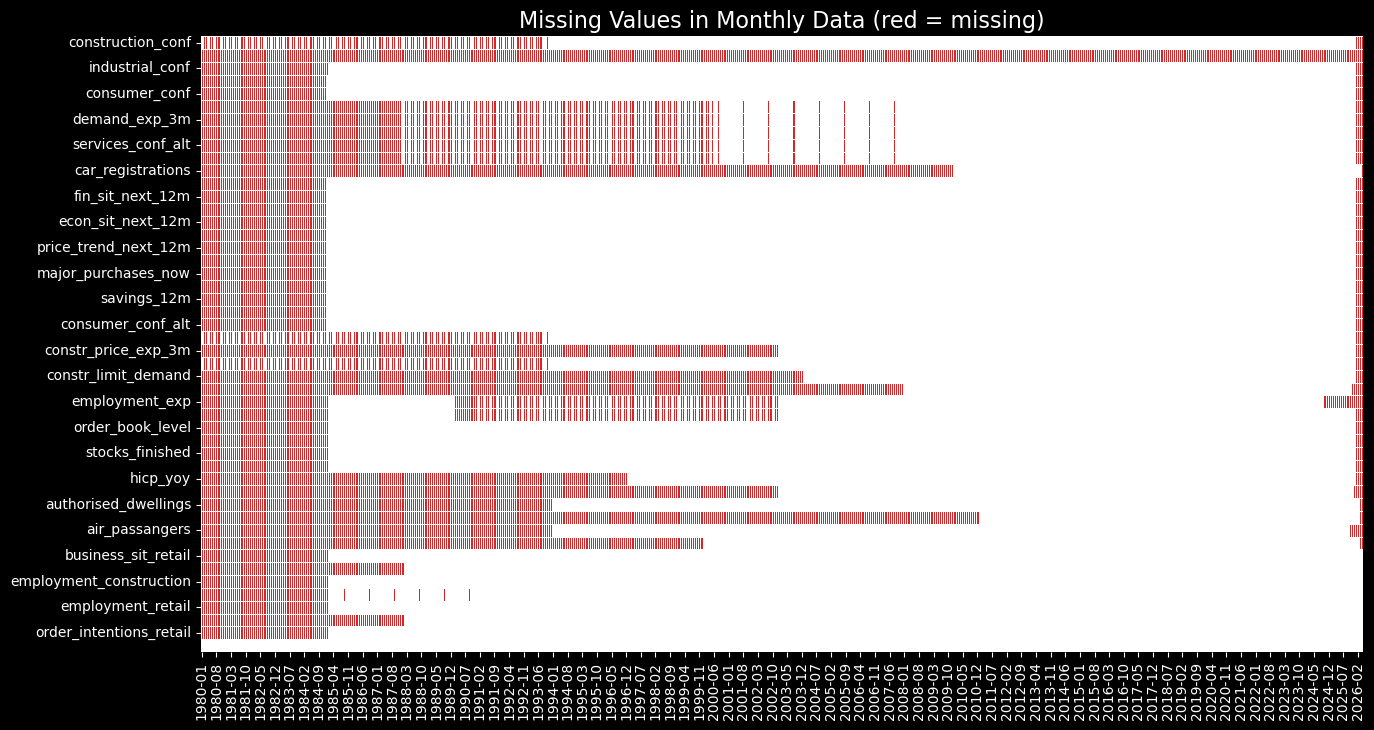

In [8]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=plot_size)
cmap = ListedColormap(['#ffffff', '#d62728'])  # blanco = no falta, rojo = falta
sns.heatmap(df_m.T.isna().astype(int), cbar=False, cmap=cmap,linewidths=0.4)
plt.title('Missing Values in Monthly Data (red = missing)', fontsize=16)

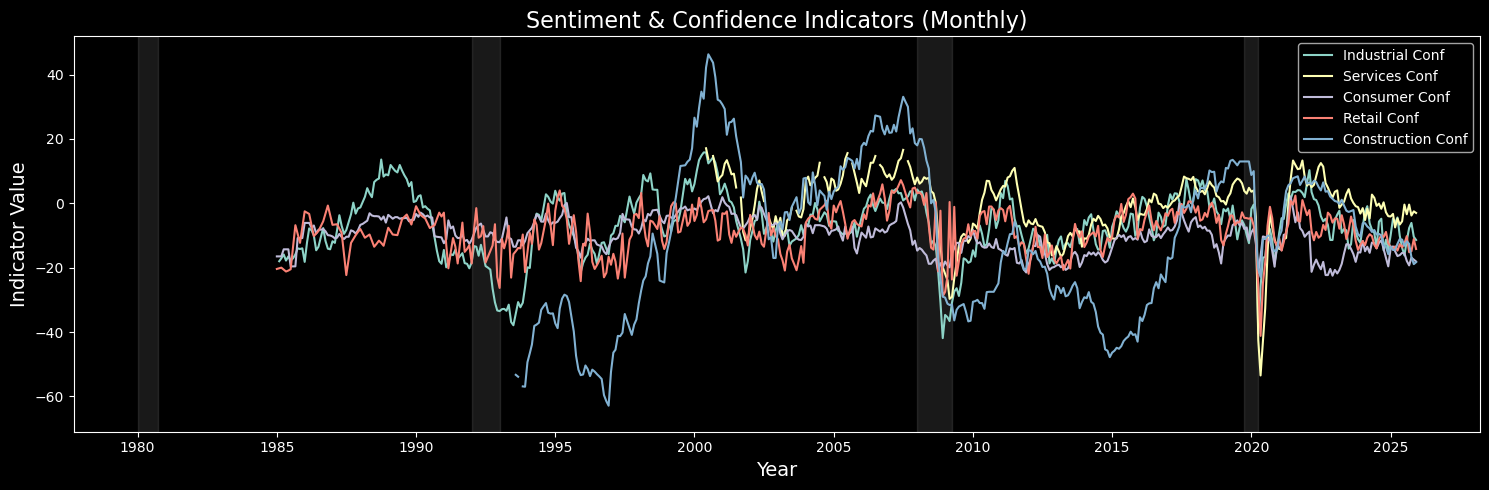

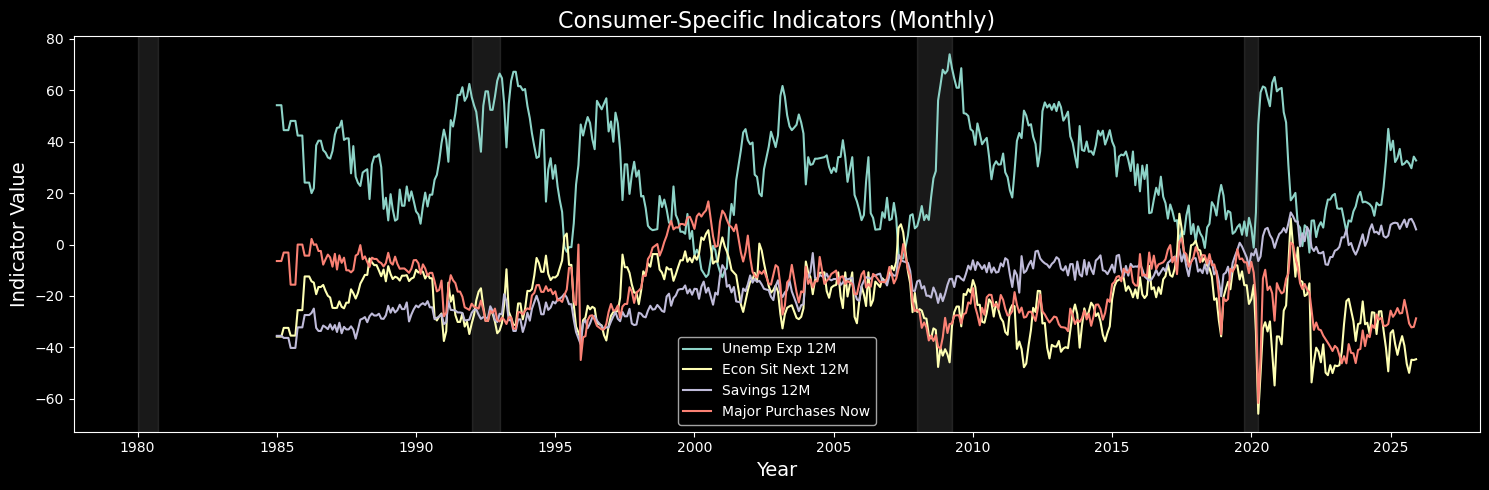

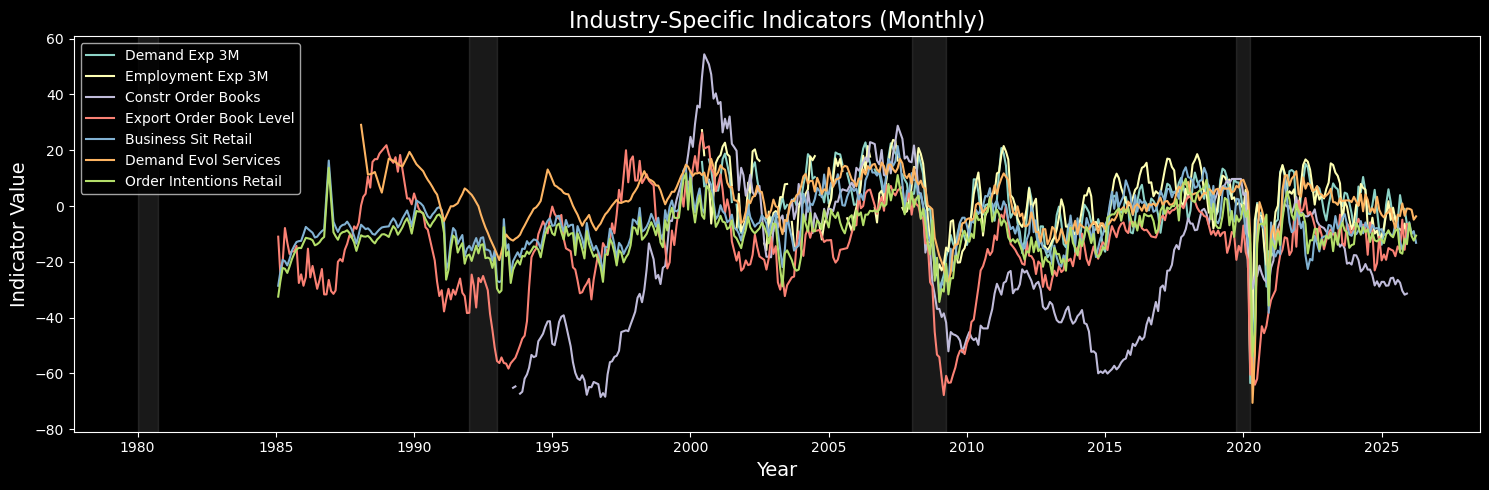

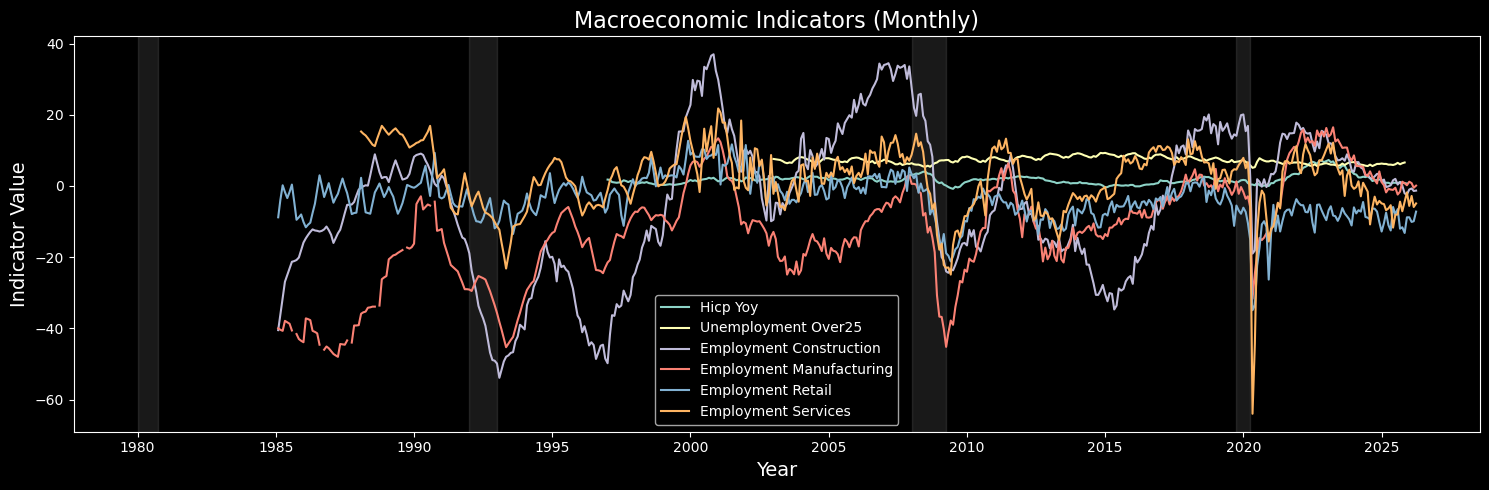

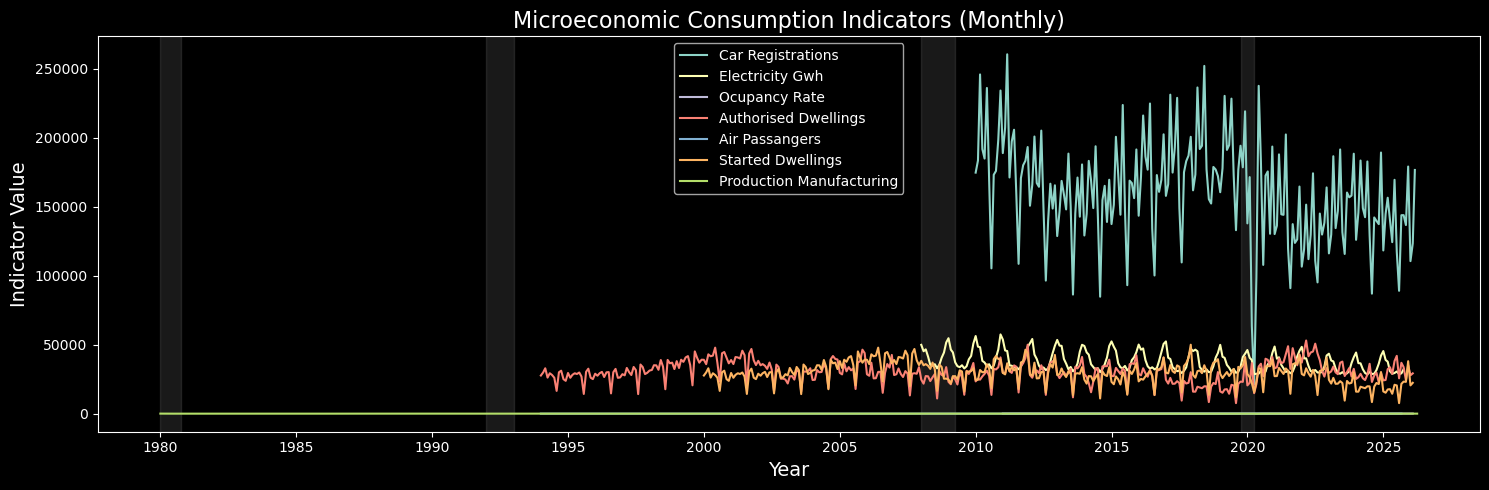

In [9]:


# Plot each group
for group_name, indicators in indicator_groups.items():
    plt.figure(figsize=(15,5))
    for ind in indicators:
        if ind in df_m.columns:
            plt.plot(df_m.index.to_timestamp(), df_m[ind], label=ind.replace("_", " ").title())
    plt.title(f"{group_name} Indicators (Monthly)", fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Indicator Value", fontsize=14)
    plt.legend()
    # Highlight recession cycles (using quarterly peaks/troughs, convert to monthly for shading)
    for start, end in zip(peaks, troughs):
        plt.axvspan(start.to_timestamp(), end.to_timestamp(), color="gray", alpha=0.2)
    plt.tight_layout()
    plt.show()

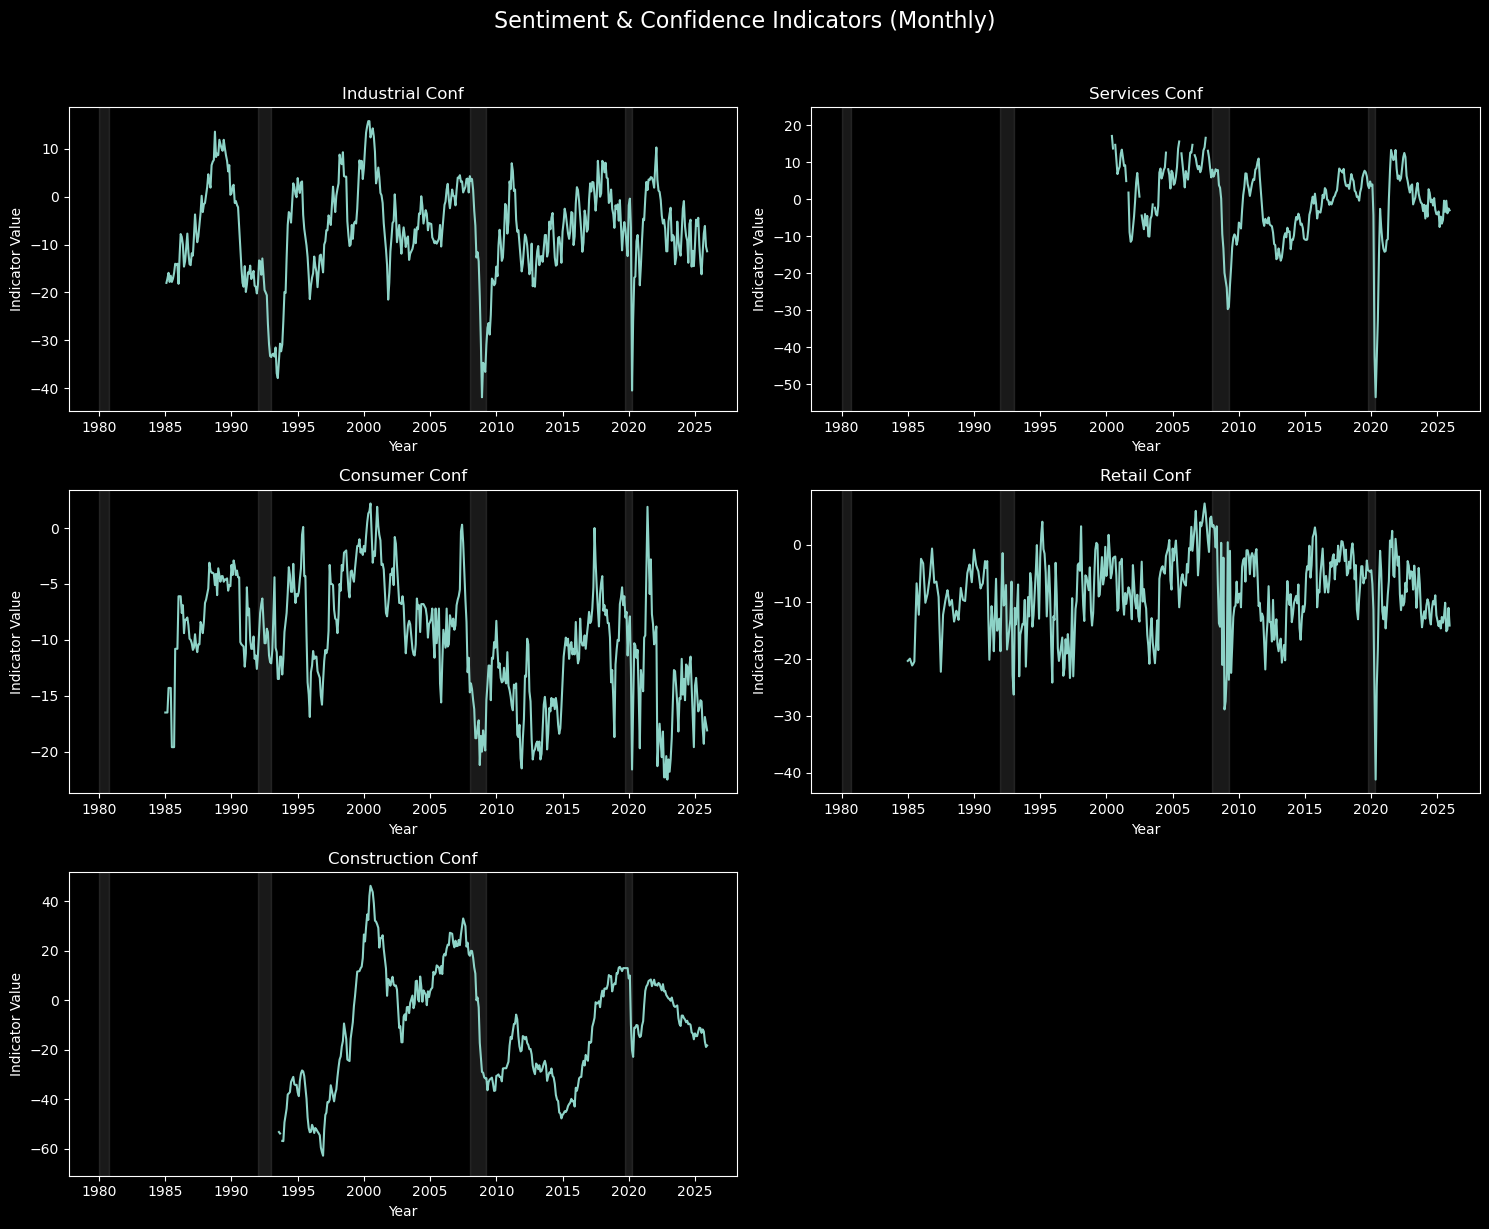

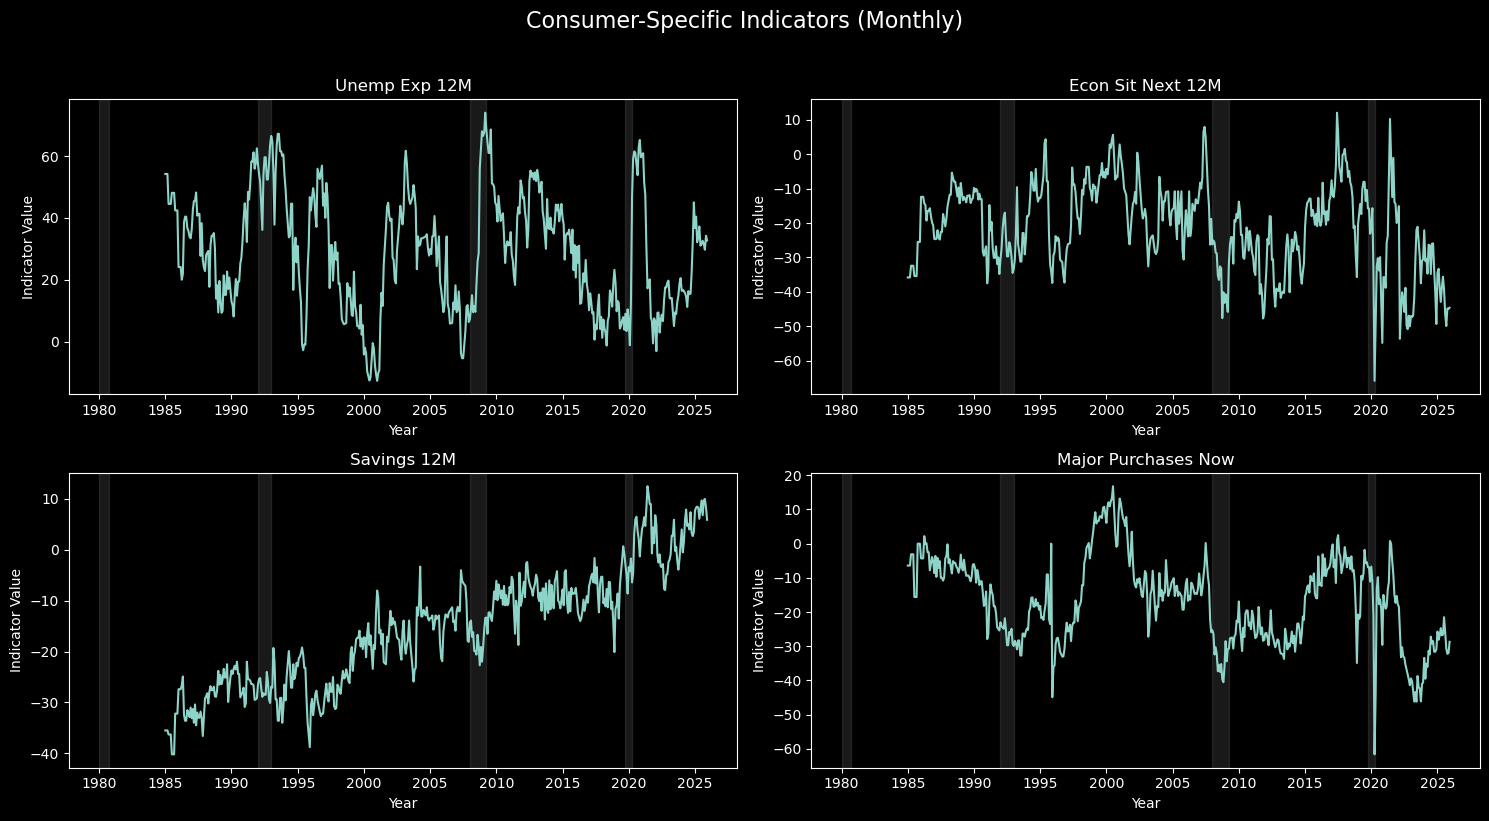

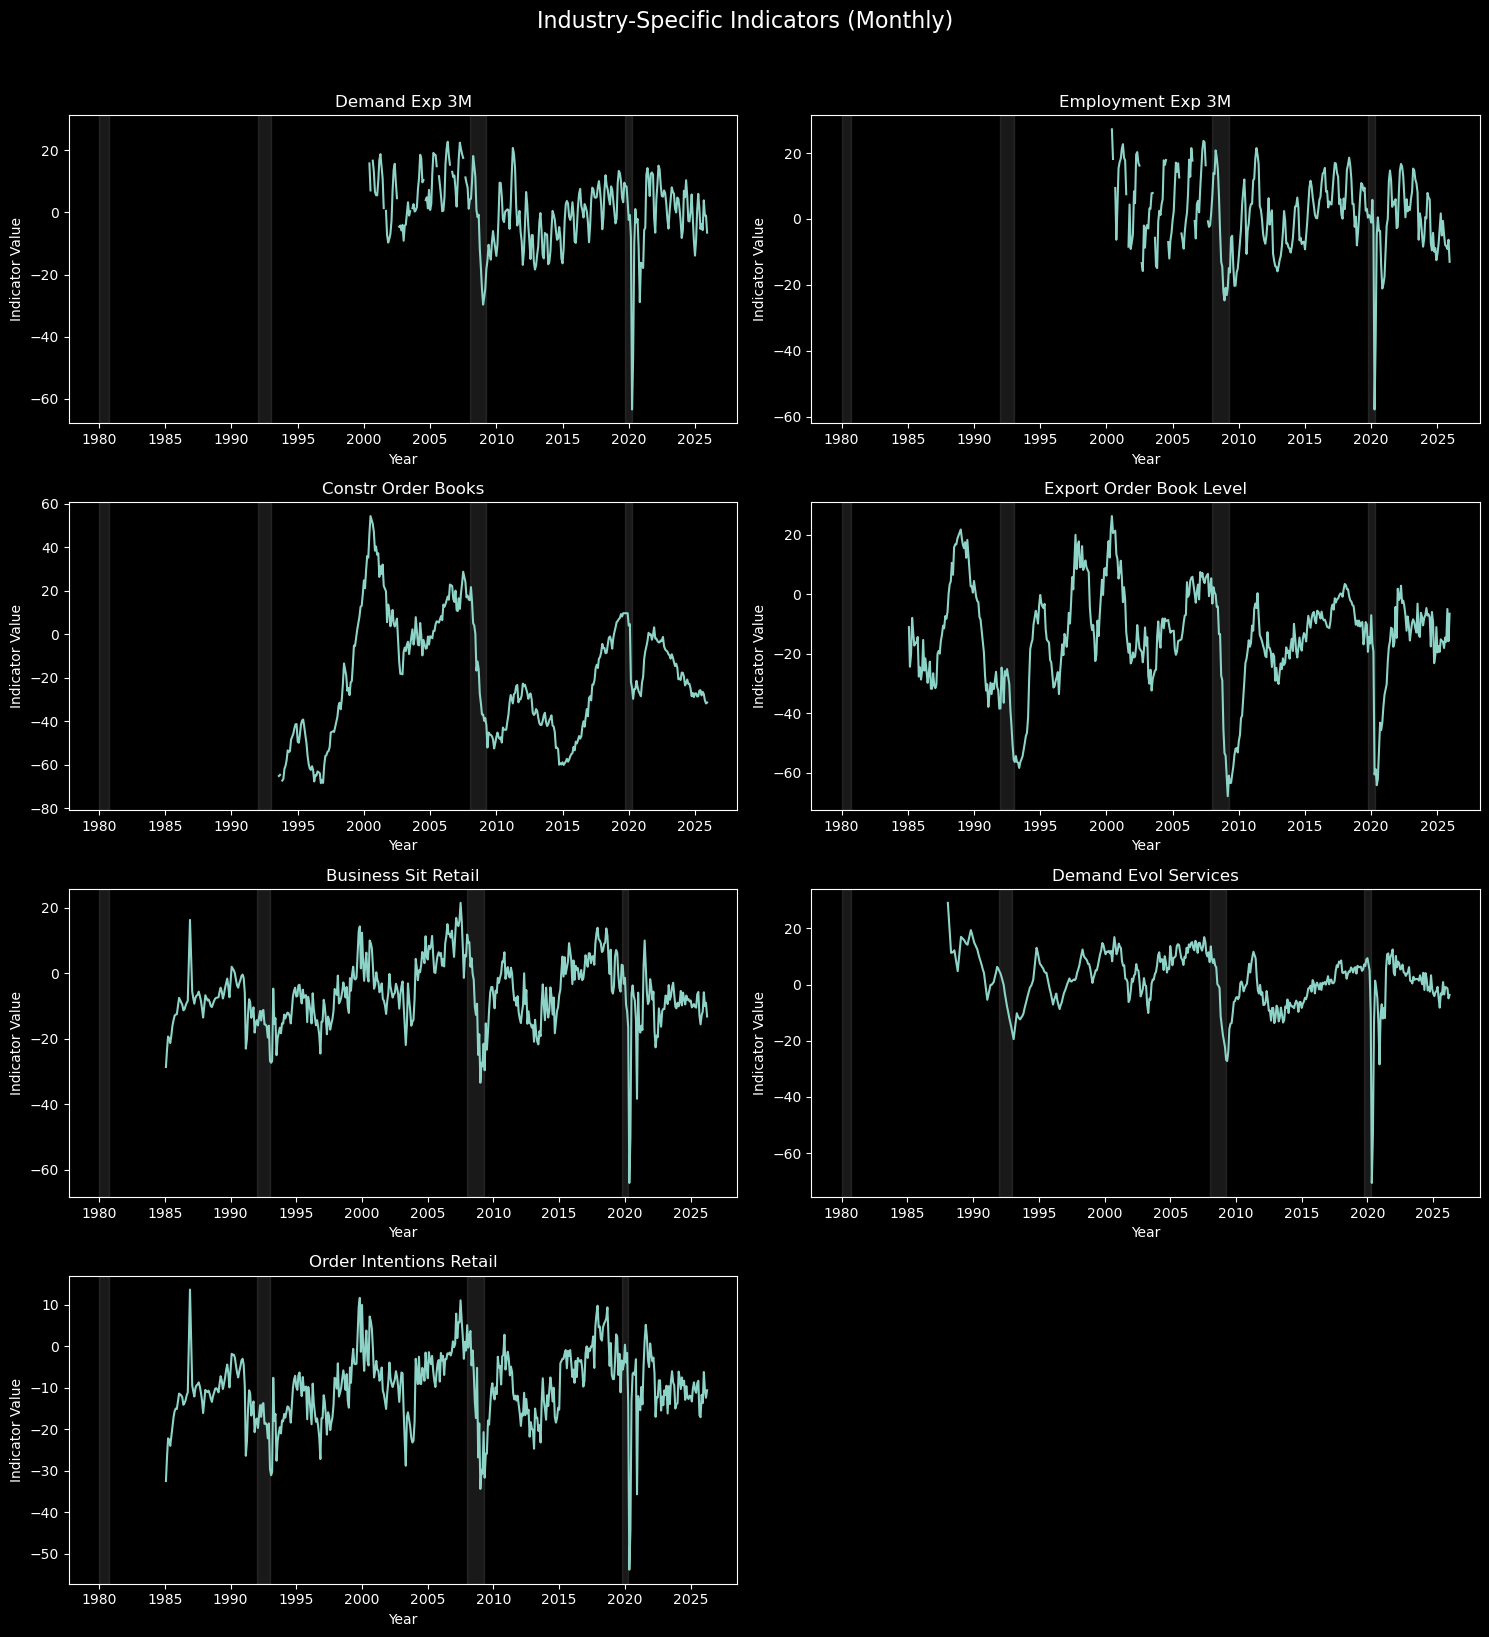

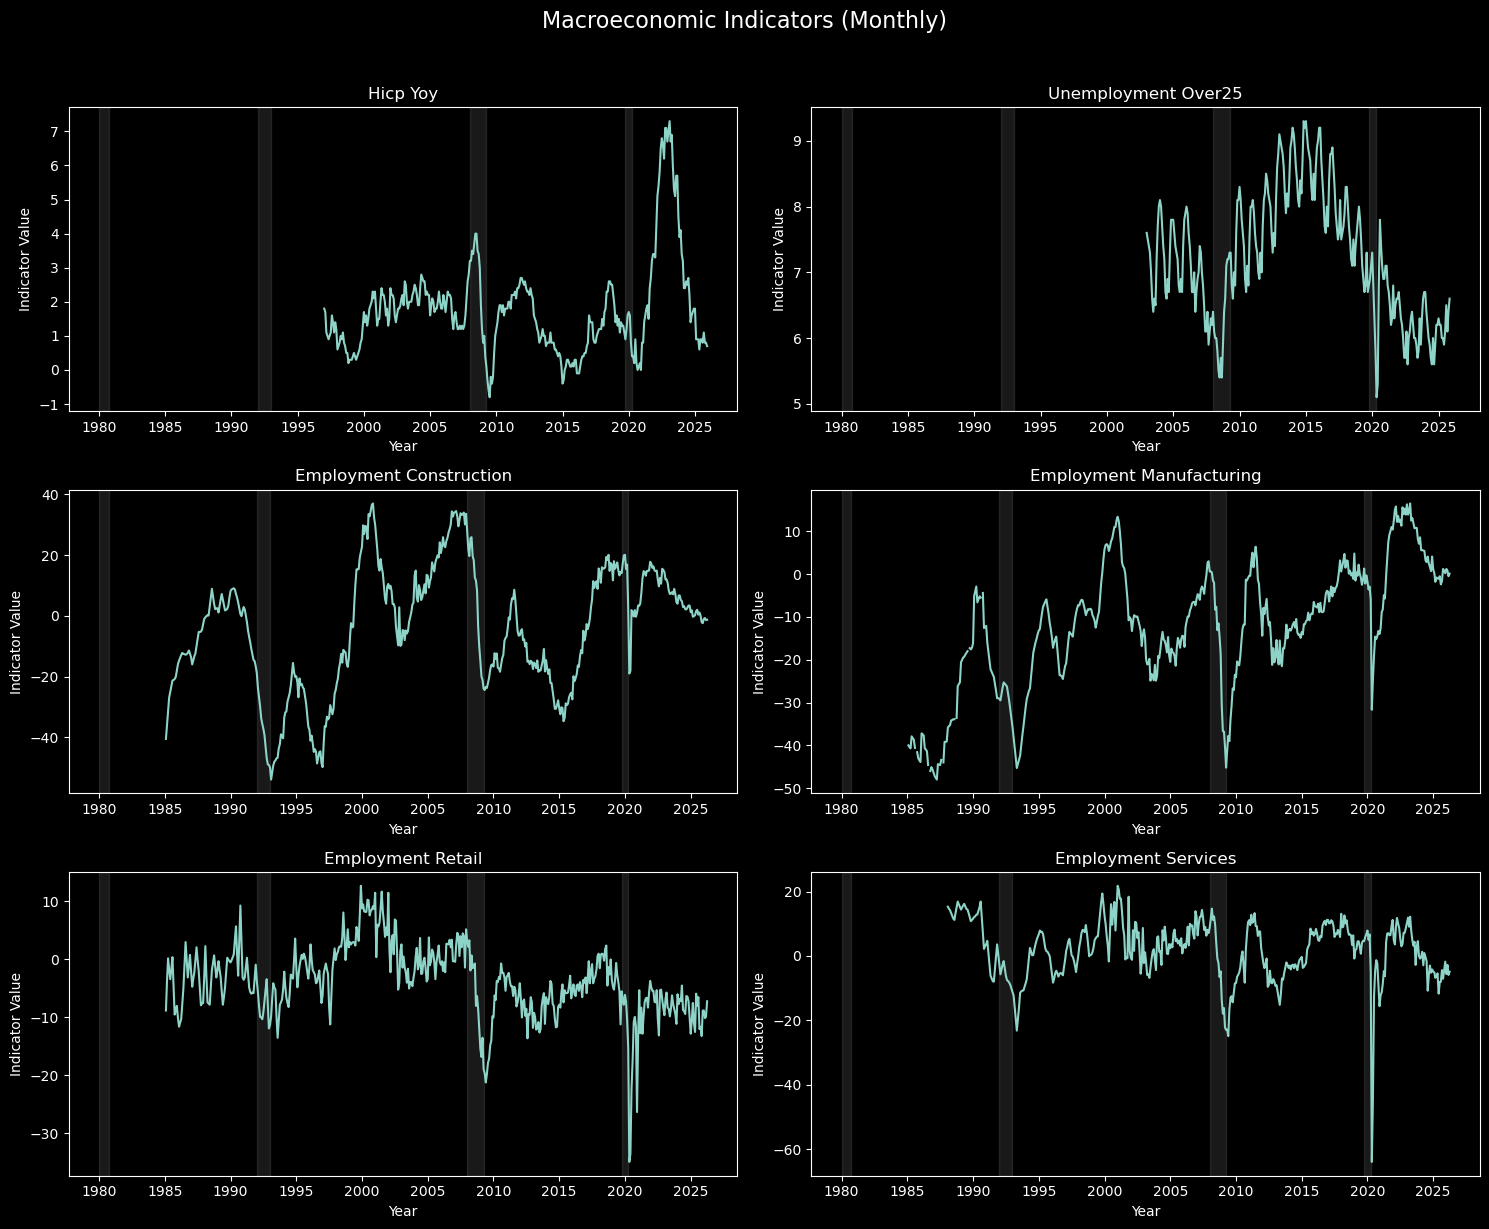

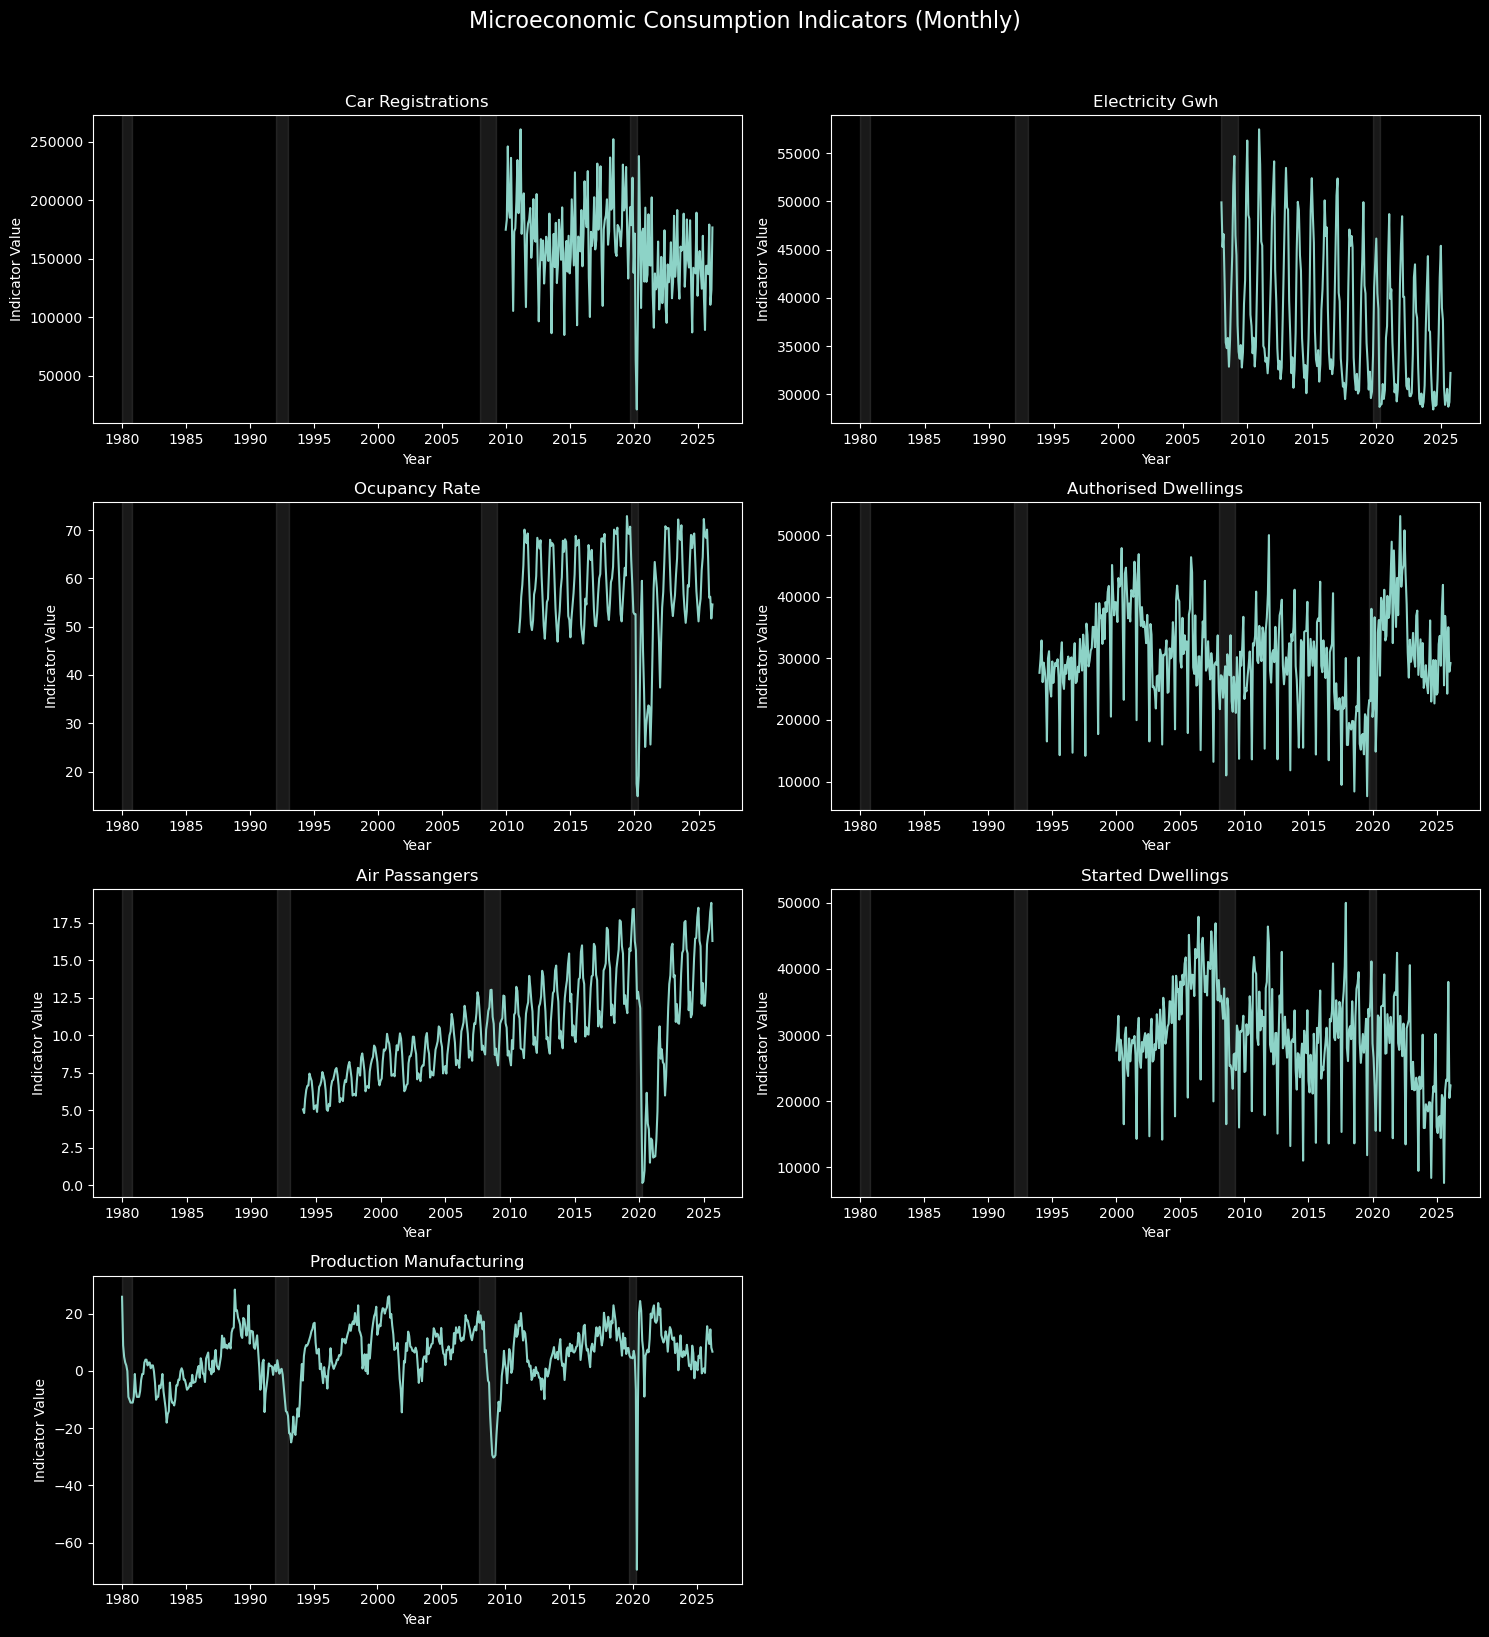

In [16]:
import math



# Plot each group
for group_name, indicators in indicator_groups.items():
    # Only keep indicators that are actually in the dataframe
    valid_indicators = [ind for ind in indicators if ind in df_m.columns]
    n_indicators = len(valid_indicators)
    
    if n_indicators == 0:
        continue
        
    # Define grid dimensions (e.g., 2 columns, calculate rows needed)
    ncols = 2
    nrows = math.ceil(n_indicators / ncols)
    
    # Create the figure and subplot grid
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    fig.suptitle(f"{group_name} Indicators (Monthly)", fontsize=16, y=1.02)
    
    # Flatten axes for easy iteration (handles single and multi-dimensional grids)
    if nrows * ncols == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()
        
    # Plot each indicator on its own axis
    for i, ind in enumerate(valid_indicators):
        ax = axes_flat[i]
        
        ax.plot(df_m.index.to_timestamp(), df_m[ind], label=ind.replace("_", " ").title())
        ax.set_title(ind.replace("_", " ").title(), fontsize=12)
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel("Indicator Value", fontsize=10)
        
        # Highlight recession cycles (using quarterly peaks/troughs, convert to monthly for shading)
        for start, end in zip(peaks, troughs):
            ax.axvspan(start.to_timestamp(), end.to_timestamp(), color="gray", alpha=0.2)
            
    # Remove any extra empty subplots if the grid isn't perfectly filled
    for j in range(n_indicators, len(axes_flat)):
        fig.delaxes(axes_flat[j])
        
    plt.tight_layout()
    plt.show()

In [21]:
# Me llevo el dataframe limpio por si quiero hacer algo más con él después
df_m.drop(columns=["economic_sentiment"], inplace=True)  
df_m.to_csv("monthly_indicators_cleaned.csv")

In [11]:
df_m.columns

Index(['construction_conf', 'economic_sentiment', 'industrial_conf',
       'retail_conf', 'consumer_conf', 'services_conf', 'demand_exp_3m',
       'employment_exp_3m', 'services_conf_alt', 'price_exp_3m',
       'car_registrations', 'fin_sit_last_12m', 'fin_sit_next_12m',
       'econ_sit_last_12m', 'econ_sit_next_12m', 'price_trend_last_12m',
       'price_trend_next_12m', 'unemp_exp_12m', 'major_purchases_now',
       'major_purchases_12m', 'savings_12m', 'fin_sit_household',
       'consumer_conf_alt', 'constr_order_books', 'constr_price_exp_3m',
       'construction_conf_alt', 'constr_limit_demand', 'electricity_gwh',
       'employment_exp', 'employment_exp_industry', 'order_book_level',
       'export_order_book_level', 'stocks_finished', 'industrial_conf_alt',
       'hicp_yoy', 'unemployment_over25', 'authorised_dwellings',
       'ocupancy_rate', 'air_passangers', 'started_dwellings',
       'business_sit_retail', 'demand_evol_services',
       'employment_construction', 'em

In [18]:
# Hacemos un dataframe con las sereis seleccionadas para computar el indicador coincidnte
selected_series = [
    "export_order_book_level",
    "unemp_exp_12m",
    "construction_conf",
    "services_conf",
    "econ_sit_next_12m",
    "car_registrations",
    "major_purchases_now",
    "industrial_conf",
    "order_book_level",
    "stocks_finished",
    "hicp_yoy",
    "constr_order_books",
    "authorised_dwellings",
    "ocupancy_rate",
    "air_passangers",
    "started_dwellings",
    "production_manufacturing",
    "employment_manufacturing",
    "employment_services",
    "demand_evol_services",
    "unemployment_over25"
]

df_m_selected = df_m[selected_series]

df_m_selected.to_csv("selected_monthly_indicators.csv", index=True)